In [1]:
!pip install mediapipe==0.10.13 -q 
#it installs MediaPipe library into your environment (the brain for pose/hand tracking)

# Can you skip it? YES if mediapipe is already installed NO if you're on Google Colab / fresh environment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 48.6 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 17.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.23 requires protobuf>=5.29.5, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 

**Phase 1 — Pose Detection**

In [2]:
import cv2
# This is OpenCV
# Used for: reading videos, processing frames (images inside video)
import mediapipe as mp
# Used for: detecting human body points (pose landmarks), Like: finding joints → shoulder, elbow, knee
import numpy as np
import pandas as pd
from pathlib import Path
# Helps handle file paths easily, Instead of messy strings → cleaner file handling
import os

# Verify GPU
import torch
print("CUDA available:", torch.cuda.is_available())

# MediaPipe setup
mp_pose = mp.solutions.pose
# Loading pose detection model, This is the brain that finds body joints
mp_drawing = mp.solutions.drawing_utils
# Tool to draw skeleton on body

# Path to your uploaded dataset — adjust dataset name to match yours on Kaggle
VIDEO_DIR = Path('/kaggle/input/datasets/jigyashmanhazarika/tennis-stroke-videos') 
OUTPUT_DIR = Path('/kaggle/working')

# Verify videos are found
video_files = sorted(VIDEO_DIR.glob('*.mp4'))
# This: searches for all .mp4 files and stores them in a list
print(f"\nFound {len(video_files)} videos:")
for v in video_files:
    print(f"  {v.name}")
    # Prints each video name

2026-04-07 13:58:19.426382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775570299.641781      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775570299.700506      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775570300.149965      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775570300.150006      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775570300.150008      55 computation_placer.cc:177] computation placer alr

CUDA available: True

Found 6 videos:
  Alcaraz video.mp4
  Roger Federer Video.mp4
  back_mixed.mp4
  back_mixed_2.mp4
  front_mixed.mp4
  side_mixed.mp4


In [3]:
import mediapipe as mp
print(mp.__version__)

# In newer mediapipe, solutions API changed
# Test which style works

# MediaPipe changed its API in newer versions, Meaning: Old code → might break, New version → different way to use
try:
    mp_pose = mp.solutions.pose
    print("solutions API works")
except AttributeError:
    print("solutions API broken — need new style")

0.10.13
solutions API works


In [4]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import urllib.request
# Helps you download files from the internet
import mediapipe as mp
# Loads MediaPipe so you can use it
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Imports specific MediaPipe modules: python → base API. vision → for image/video tasks (pose, hand, face tracking)
# Analogy: Instead of opening full toolbox, you take only: hammer (vision tools), screwdriver (tasks API)
# Can you skip it?NO if you're using pose detection / tennis tracking


print('MediaPipe version:', mp.__version__)
print('All imports successful!')

MediaPipe version: 0.10.13
All imports successful!


In [5]:
# Downloading lite model — much faster
# This cell is about downloading a lightweight pose detection model.
!wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task -O /kaggle/working/pose_landmarker_lite.task

# !wget → command to download file from internet, -q → quiet mode (no extra logs), URL → location of model, -O → where to save file
# here we are downloading the mediapipe brain from the internet
print("Lite model downloaded")

Lite model downloaded


In [6]:
# so We downloaded the brain earlier, now we are setting how it should behave
# This tells: “Where is my downloaded model file?”


model_path = '/kaggle/working/pose_landmarker_lite.task'  # <-- lite model
base_options = python.BaseOptions(model_asset_path=model_path)
# Loads this model so I can use it, BaseOptions is like plugging brain into system

options = vision.PoseLandmarkerOptions(
    # This is where we control how the model behaves
    base_options=base_options,
    output_segmentation_masks=False,
    # Means: Don’t detect full body region, Only detect keypoints (joints)
    num_poses=1,
    min_pose_detection_confidence=0.5,
    # Model must be at least 50% sure to detect a person, tar mane we are giving a strictness level here, atleast be 50 % sure, je this is a person, judi 50 t ke 80 kori diu, then strictness will be high, tetia time lagibo pare but model will be very sharp, a good one
    min_pose_presence_confidence=0.5,
    # this checks “Is a person really present? neh kiba ji ti hoi ase
    min_tracking_confidence=0.5
    # While tracking across frames: Must be at least 50% confident
)
print('Lite model ready.')

Lite model ready.


In [7]:
# in this cell we are giving human-readable names to body points (instead of confusing numbers)
# tar mane ki hoi, mediapipe or output ot generally in the form of numbers ulai, so hence this cell is used to convert those numbers to meaningful names

LANDMARKS = {
    'nose': 0,
    'left_shoulder': 11,  'right_shoulder': 12,
    'left_elbow': 13,     'right_elbow': 14,
    'left_wrist': 15,     'right_wrist': 16,
    'left_hip': 23,       'right_hip': 24,
    'left_knee': 25,      'right_knee': 26,
    'left_ankle': 27,     'right_ankle': 28
}

# so this is a landmarks dictionary, where each number is mapped to a body part, question? - numbers bur keneke gom pala are these random??
# nohoi random nohoi, mediapipe has fixed body structure, 0 mane nose, 11 mane left shoulder and so on
print('Landmarks defined.')

Landmarks defined.


In [8]:
# this cell has the core logic, This function: takes a tennis video → extracts body keypoints → returns structured data

def extract_keypoints(video_path, video_label, player_id, frame_skip=3):
    # video_path → where video is stored, video_label → name of video (like forehand/backhand), player_id → which player, frame_skip=3 → skip frames (for speed)
    cap = cv2.VideoCapture(video_path)
    # opens the video file
    fps = cap.get(cv2.CAP_PROP_FPS)
    # gets the frames per second
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # gets the total no of frames
    effective_fps = fps / frame_skip
    # real fps after skipping a few frames, final fps
    # but kio skip kori asu?? -> video has too many frames, not at all frames, the player plays a shot, hence processing all will be slow
    # hence take every 3rd frame, faster processing
    print(f'\nProcessing: {video_label} | {total} frames @ {fps:.1f} FPS')
    print(f'  Skipping every {frame_skip} frames → effective {effective_fps:.1f} FPS')
    # prints info, like kiman progress hoise tracking
    
    records = []
    # empty list to store data, each frame -> one record
    frame_idx = 0
    # frame counter

    with vision.PoseLandmarker.create_from_options(options) as landmarker:
        # now it starts the pose detection model, like start the ai brain now
        while cap.isOpened():
            # loop through each video frame, like loop until video ends
            ret, frame = cap.read()
            # read one frame, ret= false -> video ended, frame-> actual image
            if not ret:
                break
                # stop when video ends

            # Skip frames
            if frame_idx % frame_skip != 0:
                frame_idx += 1
                continue
                # skip processing -> go next frame

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # here we convert image format, OpenCV uses BGR, MediaPipe needs RGB
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            # Convert into MediaPipe format
            result = landmarker.detect(mp_image)
            # this is the main ai step, detect pose, body keypoints

            row = {
                'frame': frame_idx,
                'time_sec': frame_idx / fps,
                'video': video_label,
                'player_id': player_id,
                'fps': fps,
                'pose_detected': False
            }
            # here creating data row, store basic info for this frame
            # each frame = one row in table
            if result.pose_landmarks and len(result.pose_landmarks) > 0:
                # here, check if bode detected( if pose found)
                row['pose_detected'] = True
                # mark success
                lm = result.pose_landmarks[0]
                # take first person, since num_poses = 1
                for name, idx in LANDMARKS.items():

                    # loops through each body parts, shoulder, elbow, knee etc
                    row[f'{name}_x'] = lm[idx].x
                    row[f'{name}_y'] = lm[idx].y
                    row[f'{name}_z'] = lm[idx].z
                    row[f'{name}_vis'] = lm[idx].visibility
                    # Store: x → horizontal position, y → vertical position, z → depth, visibility → how clearly visible
                    

            records.append(row)
            # Saving row, add this frame's data
            frame_idx += 1
            # move to next frame

            if len(records) % 200 == 0:
                print(f'  {len(records)} samples collected ({frame_idx}/{total} frames)...')
                # progress print: every 200 frames, show the progress

    cap.release()
    # close video
    df = pd.DataFrame(records)
    # convert list into table
    detected = df['pose_detected'].sum()
    # counts successful detections
    print(f'  Done — pose detected in {detected}/{len(df)} samples ({100*detected/len(df):.1f}%)')
    # show detection %
    return df
    # output = dataframe
print('Function ready.')

Function ready.


In [9]:
# Test MediaPipe speed on 50 frames
import time

test_video = str(video_files[0])
cap = cv2.VideoCapture(test_video)

frame_idx = 0
times = []

with vision.PoseLandmarker.create_from_options(options) as landmarker:
    for i in range(50):
        ret, frame = cap.read()
        if not ret:
            break

        start = time.time()
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = landmarker.detect(mp_image)
        elapsed = time.time() - start
        times.append(elapsed)

        if i % 10 == 0:
            print(f"Frame {i}: {elapsed:.3f}s")

cap.release()

avg = sum(times) / len(times)
total_estimated = avg * 21532
print(f"\nAvg per frame: {avg:.3f}s")
print(f"Estimated total for Alcaraz video: {total_estimated/60:.1f} minutes")

I0000 00:00:1775570344.489937      55 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Frame 0: 0.031s
Frame 10: 0.035s
Frame 20: 0.032s
Frame 30: 0.042s
Frame 40: 0.033s

Avg per frame: 0.034s
Estimated total for Alcaraz video: 12.3 minutes


In [10]:
# this is my execution cell, It actually runs my whole project on all videos 

def get_player_id(video_stem):
    # this function decides, which player is in this video
    my_videos = ['back_mixed', 'back_mixed_2', 'front_mixed', 'side_mixed']
    # these are my videos
    if video_stem in my_videos:
        return 'jiggs'
        # here it checks if videoname matches player -> jiggs
    elif 'Alcaraz' in video_stem:
        return 'alcaraz'
        # if filename contains alcaraz
    elif 'Federer' in video_stem:
        return 'federer'
    else:
        return 'unknown'

# If no match → unknown player

all_keypoints = []
# empty list to store data from all videos

for video_path in video_files:
    # loop through all video
    player_id = get_player_id(video_path.stem)
    # extract player name, .stem means extract filename without .mp4
    print(f"\nProcessing: {video_path.name} → player_id: {player_id}")
    # show video name, detected player
    
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"  FPS: {fps:.1f}, Total frames: {total}, Est. time: {total//fps//60:.0f} min")
    cap.release()
    # close video
    
    df = extract_keypoints(str(video_path), video_path.stem, player_id)
    # Calls your main function, This does: read frames, detect pose, extract keypoints
    all_keypoints.append(df)
    # stores result of each video

keypoints_df = pd.concat(all_keypoints, ignore_index=True)
# merge all data into one big table
keypoints_df.to_csv(OUTPUT_DIR / 'keypoints.csv', index=False)
# save as csv file
print(f"\nDone. Total rows: {len(keypoints_df)}")
print(keypoints_df['player_id'].value_counts())


Processing: Alcaraz video.mp4 → player_id: alcaraz
  FPS: 30.0, Total frames: 21532, Est. time: 11 min

Processing: Alcaraz video | 21532 frames @ 30.0 FPS
  Skipping every 3 frames → effective 10.0 FPS


I0000 00:00:1775570349.435721      55 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL


  200 samples collected (598/21532 frames)...
  400 samples collected (1198/21532 frames)...
  600 samples collected (1798/21532 frames)...
  800 samples collected (2398/21532 frames)...
  1000 samples collected (2998/21532 frames)...
  1200 samples collected (3598/21532 frames)...
  1400 samples collected (4198/21532 frames)...
  1600 samples collected (4798/21532 frames)...
  1800 samples collected (5398/21532 frames)...
  2000 samples collected (5998/21532 frames)...
  2200 samples collected (6598/21532 frames)...
  2400 samples collected (7198/21532 frames)...
  2600 samples collected (7798/21532 frames)...
  2800 samples collected (8398/21532 frames)...
  3000 samples collected (8998/21532 frames)...
  3200 samples collected (9598/21532 frames)...
  3400 samples collected (10198/21532 frames)...
  3600 samples collected (10798/21532 frames)...
  3800 samples collected (11398/21532 frames)...
  4000 samples collected (11998/21532 frames)...
  4200 samples collected (12598/21532 fra

I0000 00:00:1775570598.822364      55 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL


  200 samples collected (598/15665 frames)...
  400 samples collected (1198/15665 frames)...
  600 samples collected (1798/15665 frames)...
  800 samples collected (2398/15665 frames)...
  1000 samples collected (2998/15665 frames)...
  1200 samples collected (3598/15665 frames)...
  1400 samples collected (4198/15665 frames)...
  1600 samples collected (4798/15665 frames)...
  1800 samples collected (5398/15665 frames)...
  2000 samples collected (5998/15665 frames)...
  2200 samples collected (6598/15665 frames)...
  2400 samples collected (7198/15665 frames)...
  2600 samples collected (7798/15665 frames)...
  2800 samples collected (8398/15665 frames)...
  3000 samples collected (8998/15665 frames)...
  3200 samples collected (9598/15665 frames)...
  3400 samples collected (10198/15665 frames)...
  3600 samples collected (10798/15665 frames)...
  3800 samples collected (11398/15665 frames)...
  4000 samples collected (11998/15665 frames)...
  4200 samples collected (12598/15665 fra

...

  200 samples collected (598/2122 frames)...
  400 samples collected (1198/2122 frames)...
  600 samples collected (1798/2122 frames)...
  Done — pose detected in 658/708 samples (92.9%)

Processing: front_mixed.mp4 → player_id: jiggs
  FPS: 60.0, Total frames: 2726, Est. time: 0 min

Processing: front_mixed | 2726 frames @ 60.0 FPS
  Skipping every 3 frames → effective 20.0 FPS


I0000 00:00:1775570842.294157      55 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL


  200 samples collected (598/2726 frames)...
  400 samples collected (1198/2726 frames)...
  600 samples collected (1798/2726 frames)...
  800 samples collected (2398/2726 frames)...
  Done — pose detected in 894/909 samples (98.3%)

Processing: side_mixed.mp4 → player_id: jiggs
  FPS: 30.0, Total frames: 887, Est. time: 0 min

Processing: side_mixed | 887 frames @ 30.0 FPS
  Skipping every 3 frames → effective 10.0 FPS


I0000 00:00:1775570876.721291      55 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL


  200 samples collected (598/887 frames)...
  Done — pose detected in 213/296 samples (72.0%)

Done. Total rows: 15086
player_id
alcaraz    7178
federer    5222
jiggs      2686
Name: count, dtype: int64


In [11]:
import os
# atia ami since model tuk feature keneke extract kore khikalu, atia ami nijor videos bur or logt test korim, sau kenekua kore
# heikarne ami upload korisu tennis videos nijor and then 
# we are Finding the correct path first, before testing and checking ji videos or pics upload korisu heigita e ase neh
base = '/kaggle/input/datasets/jigyashmanhazarika/tennis-stroke-videos'
print('Contents:', os.listdir(base))


Contents: ['back_mixed.mp4', 'front_mixed.mp4', 'Alcaraz video.mp4', 'back_mixed_2.mp4', 'side_mixed.mp4', 'Roger Federer Video.mp4']


In [12]:
# this cell is simple also imp, it checks all our videos and prints their details (size, fps, duration, etc.)
# before getting into it, we first look at your data, “What kind of videos do I have?
base = '/kaggle/input/datasets/jigyashmanhazarika/tennis-stroke-videos'
# this is where our videos is stored
videos = os.listdir(base)
# gets all file names inside that folder

print(f'Found {len(videos)} videos:\n')
# prints no of videos
for v in videos:
    # loop through each video, Go one by one: video1.mp4, video2.mp4, etc.
    path = os.path.join(base, v)
    # Combine folder + file name
    size = os.path.getsize(path) / (1024*1024)
    # gets size in MB
    
    # Get video properties
    import cv2
    cap = cv2.VideoCapture(path)
    # Open video (same as before)
    fps = cap.get(cv2.CAP_PROP_FPS)
    # extract video properties, frames per second
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # total frames
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    # Resolution (width × height)
    duration = frames / fps if fps > 0 else 0
    # total duration of video
    cap.release()
    # close video, free memory
    
    print(f'{v}')
    print(f'  Size: {size:.1f} MB | Resolution: {w}x{h} | FPS: {fps:.1f} | Duration: {duration:.1f}s | Frames: {frames}')
    #shows info neatly

Found 6 videos:

back_mixed.mp4
  Size: 5.7 MB | Resolution: 464x832 | FPS: 60.0 | Duration: 38.7s | Frames: 2318
front_mixed.mp4
  Size: 6.7 MB | Resolution: 464x832 | FPS: 60.0 | Duration: 45.5s | Frames: 2726
Alcaraz video.mp4
  Size: 26.6 MB | Resolution: 640x360 | FPS: 30.0 | Duration: 718.5s | Frames: 21532
back_mixed_2.mp4
  Size: 5.2 MB | Resolution: 464x832 | FPS: 60.0 | Duration: 35.4s | Frames: 2122
side_mixed.mp4
  Size: 4.6 MB | Resolution: 480x848 | FPS: 30.0 | Duration: 29.6s | Frames: 887
Roger Federer Video.mp4
  Size: 19.3 MB | Resolution: 640x360 | FPS: 30.0 | Duration: 522.7s | Frames: 15665


In [13]:
import os

# Find the real path
# locates where all the individual videos are located
for root, dirs, files in os.walk('/kaggle/input/'):
    for file in files:
        if file.endswith('.mp4'):
            print(os.path.join(root, file))

/kaggle/input/datasets/jigyashmanhazarika/tennis-stroke-videos/back_mixed.mp4
/kaggle/input/datasets/jigyashmanhazarika/tennis-stroke-videos/front_mixed.mp4
/kaggle/input/datasets/jigyashmanhazarika/tennis-stroke-videos/Alcaraz video.mp4
/kaggle/input/datasets/jigyashmanhazarika/tennis-stroke-videos/back_mixed_2.mp4
/kaggle/input/datasets/jigyashmanhazarika/tennis-stroke-videos/side_mixed.mp4
/kaggle/input/datasets/jigyashmanhazarika/tennis-stroke-videos/Roger Federer Video.mp4


In [14]:
# Verify saved correctly
keypoints_df = pd.read_csv(OUTPUT_DIR / 'keypoints.csv')
print(f"Shape: {keypoints_df.shape}")
print(f"\nColumns: {list(keypoints_df.columns[:10])}...")
print(f"\nPer video sample counts:")
print(keypoints_df.groupby(['player_id', 'video'])['frame'].count())
print(f"\nMissing values in key landmarks:")
print(keypoints_df[['left_wrist_x', 'right_wrist_x', 'left_elbow_x']].isna().sum())

Shape: (15086, 58)

Columns: ['frame', 'time_sec', 'video', 'player_id', 'fps', 'pose_detected', 'nose_x', 'nose_y', 'nose_z', 'nose_vis']...

Per video sample counts:
player_id  video              
alcaraz    Alcaraz video          7178
federer    Roger Federer Video    5222
jiggs      back_mixed              773
           back_mixed_2            708
           front_mixed             909
           side_mixed              296
Name: frame, dtype: int64

Missing values in key landmarks:
left_wrist_x     938
right_wrist_x    938
left_elbow_x     938
dtype: int64


**Phase 2 — Stroke Detection**

In [16]:
# THIS is your intelligence layer, Earlier we extracted body points, Now we are detecting actual tennis strokes


def detect_strokes_v3(df, player_id,
                       velocity_threshold=0.04,
                       min_gap_frames=40,  # increased from 20
                       window=15):
    # Input: df → your keypoints dataset, player_id → which player, other parameters → control detection
    # goal: find when a tennis stroke happens
    player_df = df[df['player_id'] == player_id].copy()
    # Take only data of one player, Example: only Federer OR only you
    all_strokes = []

    for video_name in player_df['video'].unique():
        # process each video separately
        vid_df = player_df[player_df['video'] == video_name].copy()
        # stores a copy of the video, for later use
        vid_df = vid_df[vid_df['pose_detected'] == True].reset_index(drop=True)
        # removes bad frames ( no pose)
        if len(vid_df) < 10:
            continue
        # skip very small videos

        # Compute Movement (VERY IMPORTANT)
        vid_df['lw_vx'] = vid_df['left_wrist_x'].diff().abs()
        # Change in wrist position, .diff() = movement from previous frame
        vid_df['lw_vy'] = vid_df['left_wrist_y'].diff().abs()
        vid_df['rw_vx'] = vid_df['right_wrist_x'].diff().abs()
        vid_df['rw_vy'] = vid_df['right_wrist_y'].diff().abs()
        vid_df['wrist_velocity'] = vid_df[['lw_vx','lw_vy','rw_vx','rw_vy']].max(axis=1)
        # take maximum movement of both wrists, meaning how fast hand is moving
        
        vid_df['le_vy'] = vid_df['left_elbow_y'].diff().abs()
        vid_df['re_vy'] = vid_df['right_elbow_y'].diff().abs()
        vid_df['elbow_movement'] = vid_df[['le_vy','re_vy']].max(axis=1)

        vid_df['ls_vy'] = vid_df['left_shoulder_y'].diff().abs()
        vid_df['rs_vy'] = vid_df['right_shoulder_y'].diff().abs()
        vid_df['shoulder_movement'] = vid_df[['ls_vy','rs_vy']].max(axis=1)
        # same goes for shoulder and elbow movement

        vid_df['stroke_score'] = (
            vid_df['wrist_velocity'] * 0.5 +
            vid_df['elbow_movement'] * 0.3 +
            vid_df['shoulder_movement'] * 0.2
        )

        # combine all movements into one number (Weights) but why?? big movement (or weights) = high score means possible stroke hitten
        vid_df['stroke_score_smooth'] = vid_df['stroke_score'].rolling(3, center=True).mean()
        # rolling(3, center=True).mean(), it smooths noise

        # Find peaks — only keep LOCAL maxima above threshold
        stroke_frames = []
        last_stroke = -min_gap_frames

        for i in range(1, len(vid_df) - 1):
            # checks each frame
            score = vid_df.iloc[i]['stroke_score_smooth']
            if pd.isna(score):
                continue
            prev_score = vid_df.iloc[i-1]['stroke_score_smooth']
            next_score = vid_df.iloc[i+1]['stroke_score_smooth']

            # Must be local maximum AND above threshold AND far enough from last stroke
            is_local_max = score > prev_score and score > next_score
            # peak point
            above_threshold = score > velocity_threshold
            # movement must be strong enough
            far_enough = (i - last_stroke) >= min_gap_frames
            # avoid detecting same stroke multiple times

            if is_local_max and above_threshold and far_enough:
                stroke_frames.append(i)
                last_stroke = i

            # You are basically saying: Find peaks,Only big peaks, Only spaced peaks = strokes detected

        for peak in stroke_frames:
            # For each detected stroke
            start = max(0, peak - window)
            end = min(len(vid_df), peak + window)
            # Take frames around stroke
            # means capture before + after motion

            all_strokes.append({
                'video': video_name,
                'player_id': player_id,
                'peak_frame': vid_df.iloc[peak]['frame'],
                'peak_time_sec': vid_df.iloc[peak]['time_sec'],
                'window_start': vid_df.iloc[start]['frame'],
                'window_end': vid_df.iloc[end-1]['frame'],
                'max_stroke_score': vid_df.iloc[peak]['stroke_score_smooth'],
                'n_frames_in_window': len(vid_df.iloc[start:end])
            })
            # Save: video name, player, peak frame, time, window, score

    return pd.DataFrame(all_strokes)

# Per player thresholds
player_thresholds = {
    'alcaraz': 0.04,
    'federer': 0.04,
    'jiggs':   0.025
}
# Different players = different intensity, lower threshold means detect softer strokes

all_strokes_v3 = []
for pid in keypoints_df['player_id'].unique():
    threshold = player_thresholds.get(pid, 0.04)
    strokes = detect_strokes_v3(keypoints_df, pid,
                                 velocity_threshold=threshold,
                                 min_gap_frames=40)
    print(f"{pid}: {len(strokes)} strokes detected")
    all_strokes_v3.append(strokes)

stroke_windows_df = pd.concat(all_strokes_v3, ignore_index=True)
# Merge all players
stroke_windows_df.to_csv(OUTPUT_DIR / 'stroke_windows.csv', index=False)
# save output
print(f"\nTotal: {len(stroke_windows_df)}")
print(stroke_windows_df.groupby('player_id')['peak_frame'].count())

alcaraz: 125 strokes detected
federer: 92 strokes detected
jiggs: 38 strokes detected

Total: 255
player_id
alcaraz    125
federer     92
jiggs       38
Name: peak_frame, dtype: int64


I0000 00:00:1775572654.748266      55 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL


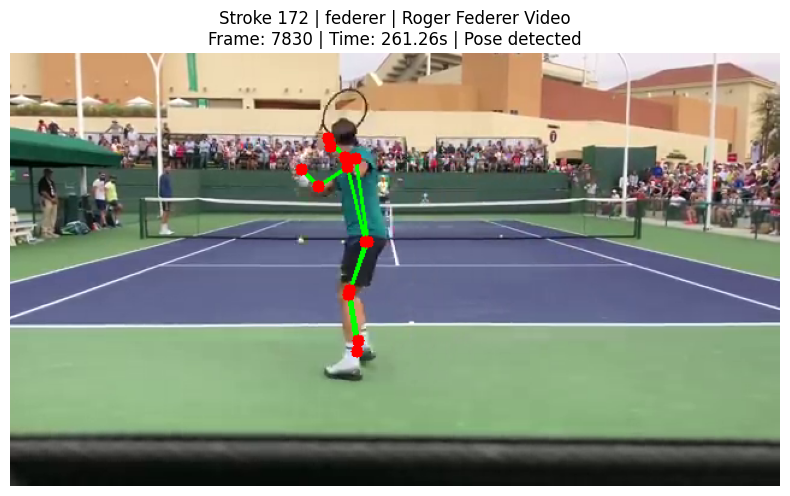

Stroke 172 → federer | Roger Federer Video | 261.26s


In [19]:
# Sanity check — visualize stroke frame for any stroke_id
def visualize_stroke(stroke_id, show_info=True):
    row = stroke_windows_df.iloc[stroke_id]
    video_name = row['video']
    peak_frame = int(row['peak_frame'])
    player_id = row['player_id']
    peak_time = row['peak_time_sec']

    # Find video file
    video_path = next(VIDEO_DIR.glob(f'*{video_name}*'), None)
    if video_path is None:
        # Try partial match
        for v in VIDEO_DIR.glob('*.mp4'):
            if any(word in v.stem for word in video_name.split()):
                video_path = v
                break
    if video_path is None:
        print(f"Video file not found for: {video_name}")
        return

    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, peak_frame)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Could not read frame {peak_frame}")
        return

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

    with vision.PoseLandmarker.create_from_options(options) as landmarker:
        result = landmarker.detect(mp_image)

    annotated = rgb.copy()
    if result.pose_landmarks and len(result.pose_landmarks) > 0:
        lm = result.pose_landmarks[0]
        h, w = annotated.shape[:2]

        connections = [
            (11,12),(11,13),(13,15),(12,14),(14,16),
            (11,23),(12,24),(23,24),(23,25),(24,26),
            (25,27),(26,28)
        ]
        for a, b in connections:
            x1, y1 = int(lm[a].x * w), int(lm[a].y * h)
            x2, y2 = int(lm[b].x * w), int(lm[b].y * h)
            cv2.line(annotated, (x1,y1), (x2,y2), (0,255,0), 2)

        for name, idx in LANDMARKS.items():
            x, y = int(lm[idx].x * w), int(lm[idx].y * h)
            cv2.circle(annotated, (x, y), 5, (255,0,0), -1)

        pose_status = "Pose detected"
    else:
        pose_status = "No pose detected"

    plt.figure(figsize=(8, 6))
    plt.imshow(annotated)
    if show_info:
        plt.title(f"Stroke {stroke_id} | {player_id} | {video_name}\n"
                  f"Frame: {peak_frame} | Time: {peak_time:.2f}s | {pose_status}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"Stroke {stroke_id} → {player_id} | {video_name} | {peak_time:.2f}s")

# Test it — change stroke_id to any number 0-254
visualize_stroke(stroke_id=172)

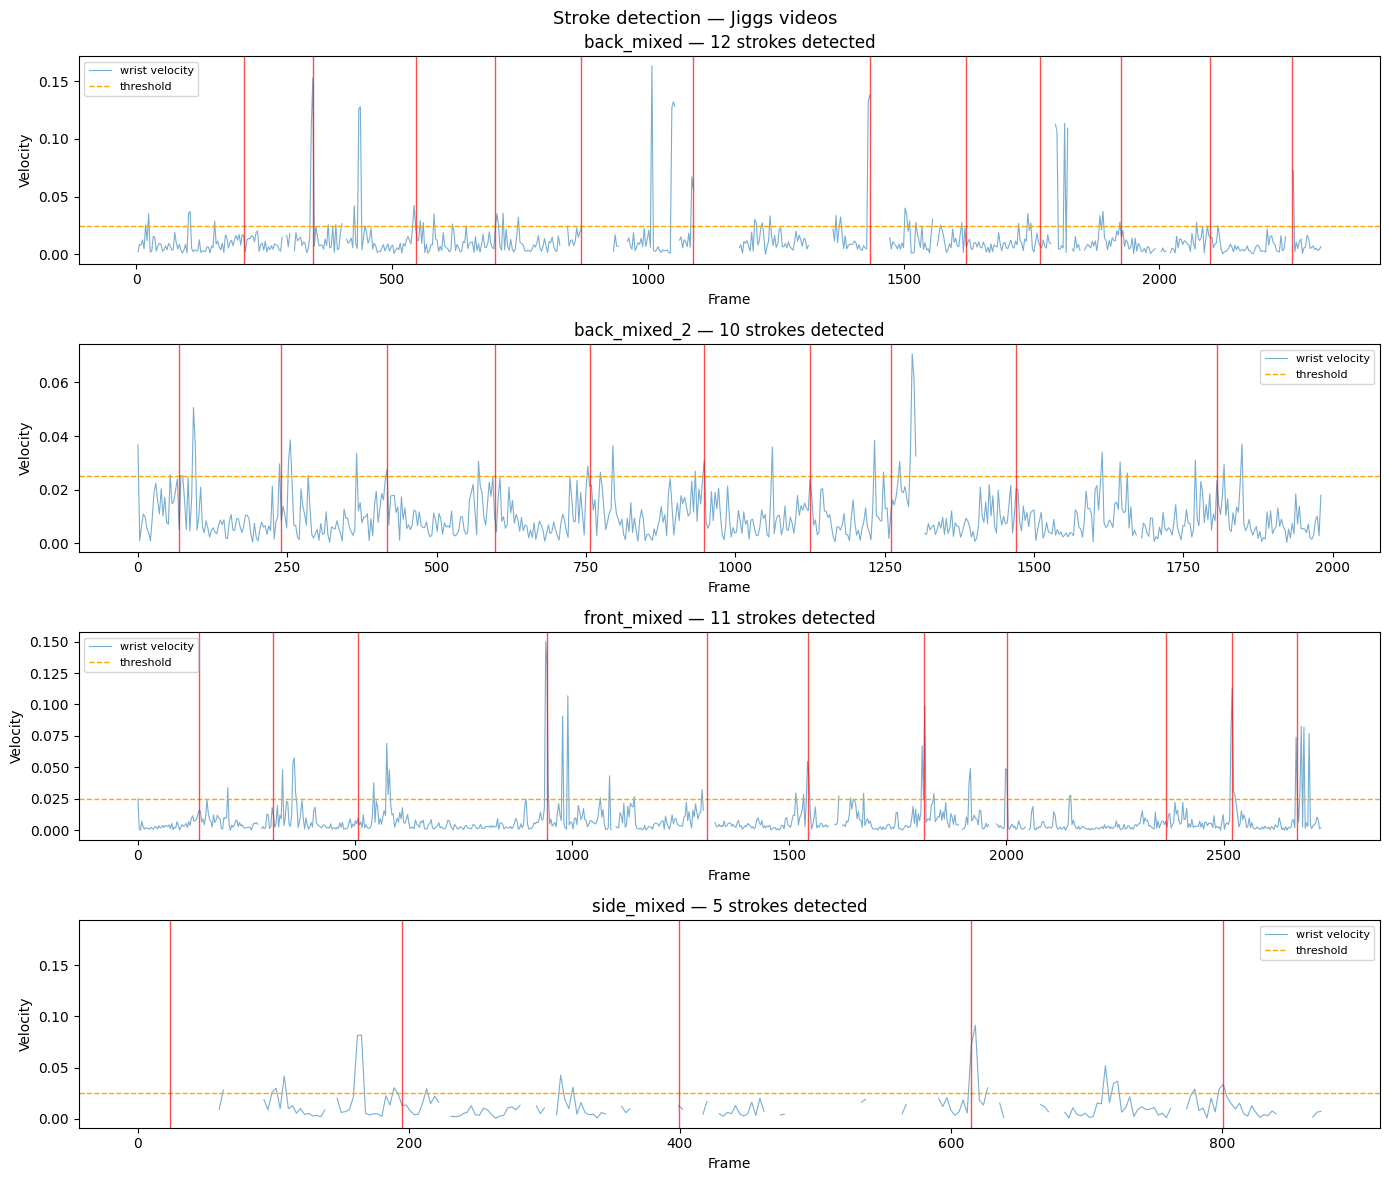

In [20]:
# Visualize stroke timing for your videos
import matplotlib.pyplot as plt

jiggs_strokes = stroke_windows_df[stroke_windows_df['player_id'] == 'jiggs']
jiggs_keypoints = keypoints_df[keypoints_df['player_id'] == 'jiggs'].copy()

# Compute stroke score for plotting
jiggs_keypoints['lw_vy'] = jiggs_keypoints['left_wrist_y'].diff().abs()
jiggs_keypoints['rw_vy'] = jiggs_keypoints['right_wrist_y'].diff().abs()
jiggs_keypoints['wrist_velocity'] = jiggs_keypoints[['lw_vy','rw_vy']].max(axis=1)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Stroke detection — Jiggs videos', fontsize=13)

for ax, video_name in zip(axes, jiggs_keypoints['video'].unique()):
    vid_kp = jiggs_keypoints[jiggs_keypoints['video'] == video_name]
    vid_strokes = jiggs_strokes[jiggs_strokes['video'] == video_name]

    ax.plot(vid_kp['frame'], vid_kp['wrist_velocity'], 
            alpha=0.6, linewidth=0.8, label='wrist velocity')
    ax.axhline(0.025, color='orange', linestyle='--', linewidth=1, label='threshold')

    for _, stroke in vid_strokes.iterrows():
        ax.axvline(stroke['peak_frame'], color='red', alpha=0.7, linewidth=1)

    ax.set_title(f"{video_name} — {len(vid_strokes)} strokes detected")
    ax.set_xlabel('Frame')
    ax.set_ylabel('Velocity')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/kaggle/working/stroke_detection_jiggs.png', dpi=150, bbox_inches='tight')
plt.show()

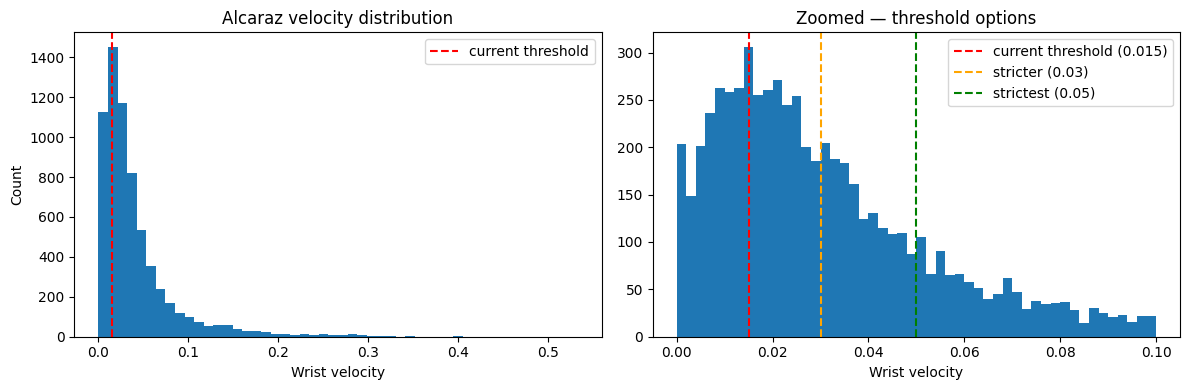

Frames above 0.015: 4867
Frames above 0.030: 3042
Frames above 0.050: 1631


In [20]:
# Check velocity distribution to see if threshold needs tuning
import matplotlib.pyplot as plt

alcaraz_df = keypoints_df[
    (keypoints_df['player_id'] == 'alcaraz') &
    (keypoints_df['pose_detected'] == True)
].copy()

alcaraz_df['lw_vy'] = alcaraz_df['left_wrist_y'].diff().abs()
alcaraz_df['rw_vy'] = alcaraz_df['right_wrist_y'].diff().abs()
alcaraz_df['wrist_velocity'] = alcaraz_df[['lw_vy', 'rw_vy']].max(axis=1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(alcaraz_df['wrist_velocity'].dropna(), bins=50)
plt.axvline(0.015, color='red', linestyle='--', label='current threshold')
plt.xlabel('Wrist velocity')
plt.ylabel('Count')
plt.title('Alcaraz velocity distribution')
plt.legend()

plt.subplot(1, 2, 2)
# Zoom into lower end
plt.hist(alcaraz_df['wrist_velocity'].dropna(), bins=50, range=(0, 0.1))
plt.axvline(0.015, color='red', linestyle='--', label='current threshold (0.015)')
plt.axvline(0.03, color='orange', linestyle='--', label='stricter (0.03)')
plt.axvline(0.05, color='green', linestyle='--', label='strictest (0.05)')
plt.xlabel('Wrist velocity')
plt.title('Zoomed — threshold options')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Frames above 0.015: {(alcaraz_df['wrist_velocity'] > 0.015).sum()}")
print(f"Frames above 0.030: {(alcaraz_df['wrist_velocity'] > 0.030).sum()}")
print(f"Frames above 0.050: {(alcaraz_df['wrist_velocity'] > 0.050).sum()}")

In [21]:
# Verify both files saved correctly
import os

files = ['keypoints.csv', 'stroke_windows.csv']
for f in files:
    path = OUTPUT_DIR / f
    if path.exists():
        df = pd.read_csv(path)
        print(f"{f}: {df.shape} — OK")
    else:
        print(f"{f}: MISSING")

keypoints.csv: (15086, 58) — OK
stroke_windows.csv: (255, 8) — OK


In [22]:
# V2 stroke summary
print('Stroke Detection Summary — V2')
print('=' * 40)
print(f'Total stroke windows : {len(stroke_windows_df)}')
print()
print(stroke_windows_df.groupby(['player_id', 'video'])['peak_frame'].count().to_string())
print()
print(f"Avg window size: {stroke_windows_df['n_frames_in_window'].mean():.1f} frames")
print(f"Min window size: {stroke_windows_df['n_frames_in_window'].min()}")
print(f"Max window size: {stroke_windows_df['n_frames_in_window'].max()}")

# Check overlaps
print('\nChecking overlapping windows per video...')
for video in stroke_windows_df['video'].unique():
    vid = stroke_windows_df[stroke_windows_df['video'] == video].sort_values('window_start')
    overlaps = 0
    for i in range(len(vid)-1):
        if vid.iloc[i]['window_end'] > vid.iloc[i+1]['window_start']:
            overlaps += 1
    print(f"  {video}: {overlaps} overlapping windows")

Stroke Detection Summary — V2
Total stroke windows : 255

player_id  video              
alcaraz    Alcaraz video          125
federer    Roger Federer Video     92
jiggs      back_mixed              12
           back_mixed_2            10
           front_mixed             11
           side_mixed               5

Avg window size: 29.9 frames
Min window size: 18
Max window size: 30

Checking overlapping windows per video...
  Alcaraz video: 0 overlapping windows
  Roger Federer Video: 0 overlapping windows
  back_mixed: 0 overlapping windows
  back_mixed_2: 0 overlapping windows
  front_mixed: 0 overlapping windows
  side_mixed: 0 overlapping windows


**Phase 3: Annotation**

In [23]:
# Export jiggs strokes for manual labeling
jiggs_strokes = stroke_windows_df[stroke_windows_df['player_id'] == 'jiggs'].copy()
jiggs_strokes = jiggs_strokes.reset_index(drop=True)
jiggs_strokes['stroke_id'] = jiggs_strokes.index

# Add empty label columns
jiggs_strokes['direction'] = ''      # cross_court / down_the_line / body
jiggs_strokes['stroke_type'] = ''    # forehand / backhand / serve
jiggs_strokes['posture_quality'] = '' # good / ok / poor

# Export
jiggs_strokes[['stroke_id', 'video', 'peak_time_sec', 
               'direction', 'stroke_type', 'posture_quality']].to_csv(
    OUTPUT_DIR / 'jiggs_labels_todo.csv', index=False
)

print(f"Generated {len(jiggs_strokes)} strokes to label")
print("\nTimestamps to review:")
print(jiggs_strokes[['stroke_id','video','peak_time_sec']].to_string())

Generated 38 strokes to label

Timestamps to review:
    stroke_id         video  peak_time_sec
0           0    back_mixed       3.502114
1           1    back_mixed       5.753473
2           2    back_mixed       9.105496
3           3    back_mixed      11.707066
4           4    back_mixed      14.508758
5           5    back_mixed      18.160962
6           6    back_mixed      23.914435
7           7    back_mixed      27.066337
8           8    back_mixed      29.467787
9           9    back_mixed      32.119387
10         10    back_mixed      35.021139
11         11    back_mixed      37.672739
12         12  back_mixed_2       1.150705
13         13  back_mixed_2       4.002451
14         14  back_mixed_2       6.954258
15         15  back_mixed_2       9.956096
16         16  back_mixed_2      12.607719
17         17  back_mixed_2      15.809680
18         18  back_mixed_2      18.761487
19         19  back_mixed_2      21.012865
20         20  back_mixed_2      24.515009
2

In [24]:
# Generate master labeling CSV for all strokes
label_df = stroke_windows_df.copy()
label_df = label_df.reset_index(drop=True)
label_df['stroke_id'] = label_df.index

# Add empty columns to fill in
label_df['direction'] = ''       # cross_court / down_the_line / body
label_df['stroke_type'] = ''     # forehand / backhand / serve
label_df['posture_quality'] = '' # good / ok / poor

# Export clean labeling sheet
export_cols = ['stroke_id', 'player_id', 'video', 
               'peak_time_sec', 'direction', 
               'stroke_type', 'posture_quality']

label_df[export_cols].to_csv(OUTPUT_DIR / 'labels_todo.csv', index=False)

print(f"Total strokes to label: {len(label_df)}")
print(f"\nBreakdown:")
print(label_df.groupby(['player_id', 'video'])['stroke_id'].count().to_string())
print(f"\nLabel options:")
print("  direction      : cross_court / down_the_line / body")
print("  stroke_type    : forehand / backhand / serve")
print("  posture_quality: good / ok / poor")
print(f"\nSaved to /kaggle/working/labels_todo.csv")
print("Download this file, fill it in, re-upload when done.")

Total strokes to label: 255

Breakdown:
player_id  video              
alcaraz    Alcaraz video          125
federer    Roger Federer Video     92
jiggs      back_mixed              12
           back_mixed_2            10
           front_mixed             11
           side_mixed               5

Label options:
  direction      : cross_court / down_the_line / body
  stroke_type    : forehand / backhand / serve
  posture_quality: good / ok / poor

Saved to /kaggle/working/labels_todo.csv
Download this file, fill it in, re-upload when done.


In [25]:
# Print timestamps with correct stroke_id matching labels_todo.csv
for video in stroke_windows_df['video'].unique():
    vid = stroke_windows_df[stroke_windows_df['video'] == video].copy()
    vid = vid.reset_index(drop=True)
    player = vid['player_id'].iloc[0]
    
    # Get the actual CSV row indices for this video
    csv_indices = stroke_windows_df[stroke_windows_df['video'] == video].index.tolist()
    
    print(f"\n{'='*50}")
    print(f"Video: {video} | Player: {player} | {len(vid)} strokes")
    print(f"{'='*50}")
    print(f"{'CSV Row':<12} {'Time (sec)':<14} {'Time (min:sec)'}")
    print(f"{'-'*40}")
    
    for i, (_, row) in enumerate(vid.iterrows()):
        t = row['peak_time_sec']
        mins = int(t // 60)
        secs = t % 60
        csv_row = csv_indices[i]  # this matches stroke_id in labels_todo.csv
        print(f"  {csv_row:<12} {t:<14.2f} {mins}:{secs:05.2f}")


Video: Alcaraz video | Player: alcaraz | 125 strokes
CSV Row      Time (sec)     Time (min:sec)
----------------------------------------
  0            4.50           0:04.50
  1            11.81          0:11.81
  2            17.22          0:17.22
  3            22.22          0:22.22
  4            27.33          0:27.33
  5            35.34          0:35.34
  6            40.64          0:40.64
  7            45.65          0:45.65
  8            50.65          0:50.65
  9            55.26          0:55.26
  10           60.26          1:00.26
  11           64.96          1:04.96
  12           69.87          1:09.87
  13           76.18          1:16.18
  14           80.58          1:20.58
  15           85.59          1:25.59
  16           90.89          1:30.89
  17           95.80          1:35.80
  18           100.80         1:40.80
  19           106.11         1:46.11
  20           111.51         1:51.51
  21           116.62         1:56.62
  22           122.02     

In [26]:
import os

path = '/kaggle/input/datasets/jigyashmanhazarika/labels-template/labels_todo(in).csv'
print('File exists:', os.path.exists(path))
print('Size:', os.path.getsize(path), 'bytes')

# Also list everything in working directory
print('\nAll files in /kaggle/working/:')
for f in os.listdir('/kaggle/working/'):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f'  {f} — {size} bytes')

File exists: True
Size: 16530 bytes

All files in /kaggle/working/:
  .virtual_documents — 4096 bytes
  keypoints.csv — 15271411 bytes
  labels_todo.csv — 12418 bytes
  pose_landmarker_lite.task — 5777746 bytes
  jiggs_labels_todo.csv — 1428 bytes
  stroke_windows.csv — 20674 bytes
  stroke_detection_jiggs.png — 383833 bytes


In [27]:
# Load your completed labels
labels_df = pd.read_csv('/kaggle/input/datasets/jigyashmanhazarika/labels-template/labels_todo(in).csv')

print(f"Shape: {labels_df.shape}")
print(f"\nColumns: {list(labels_df.columns)}")
print(f"\nFirst few rows:")
print(labels_df.head())

print(f"\nLabel completeness:")
print(f"  direction filled:       {labels_df['direction'].notna().sum()} / {len(labels_df)}")
print(f"  stroke_type filled:     {labels_df['stroke_type'].notna().sum()} / {len(labels_df)}")
print(f"  posture_quality filled: {labels_df['posture_quality'].notna().sum()} / {len(labels_df)}")

print(f"\nDirection distribution:")
print(labels_df['direction'].value_counts())

print(f"\nStroke type distribution:")
print(labels_df['stroke_type'].value_counts())

print(f"\nPosture quality distribution:")
print(labels_df['posture_quality'].value_counts())

Shape: (255, 7)

Columns: ['stroke_id', 'player_id', 'video', 'peak_time_sec', 'direction', 'stroke_type', 'posture_quality']

First few rows:
   stroke_id player_id          video  peak_time_sec    direction stroke_type  \
0          0   alcaraz  Alcaraz video       4.504505       centre    forehand   
1          1   alcaraz  Alcaraz video      11.811812  cross-court    backhand   
2          2   alcaraz  Alcaraz video      17.217217       centre    forehand   
3          3   alcaraz  Alcaraz video      22.222222       centre    forehand   
4          4   alcaraz  Alcaraz video      27.327327       centre    forehand   

  posture_quality  
0             bad  
1            good  
2            good  
3            good  
4            good  

Label completeness:
  direction filled:       255 / 255
  stroke_type filled:     255 / 255
  posture_quality filled: 255 / 255

Direction distribution:
direction
centre           92
cross-court      90
down the line    73
Name: count, dtype: int64


In [28]:
# Standardize label values
labels_df['direction'] = labels_df['direction'].str.strip().str.lower()
labels_df['direction'] = labels_df['direction'].replace({
    'cross-court': 'cross_court',
    'cross court': 'cross_court',
    'down the line': 'down_the_line',
    'down-the-line': 'down_the_line',
    'centre': 'center',
    'center': 'center'
})

labels_df['stroke_type'] = labels_df['stroke_type'].str.strip().str.lower()
labels_df['posture_quality'] = labels_df['posture_quality'].str.strip().str.lower()

# Verify
print("Direction:", labels_df['direction'].unique())
print("Stroke type:", labels_df['stroke_type'].unique())
print("Posture quality:", labels_df['posture_quality'].unique())

# Save cleaned version
labels_df.to_csv('/kaggle/working/labels_clean.csv', index=False)
print("\nSaved labels_clean.csv")

Direction: ['center' 'cross_court' 'down_the_line']
Stroke type: ['forehand' 'backhand']
Posture quality: ['bad' 'good']

Saved labels_clean.csv


**Phase 4 feature extraction**

In [29]:
from sklearn.preprocessing import LabelEncoder
import json

# Encode labels
direction_enc = LabelEncoder()
stroke_enc = LabelEncoder()
posture_enc = LabelEncoder()

labels_df['direction_label'] = direction_enc.fit_transform(labels_df['direction'])
labels_df['stroke_label'] = stroke_enc.fit_transform(labels_df['stroke_type'])
labels_df['posture_label'] = posture_enc.fit_transform(labels_df['posture_quality'])

# Save encoder mappings so we can decode predictions later
mappings = {
    'direction': dict(zip(direction_enc.classes_.tolist(), 
                         range(len(direction_enc.classes_)))),
    'stroke_type': dict(zip(stroke_enc.classes_.tolist(), 
                            range(len(stroke_enc.classes_)))),
    'posture_quality': dict(zip(posture_enc.classes_.tolist(), 
                                range(len(posture_enc.classes_))))
}

with open('/kaggle/working/label_encodings.json', 'w') as f:
    json.dump(mappings, f, indent=2)

print("Label encodings:")
for task, mapping in mappings.items():
    print(f"  {task}: {mapping}")

Label encodings:
  direction: {'center': 0, 'cross_court': 1, 'down_the_line': 2}
  stroke_type: {'backhand': 0, 'forehand': 1}
  posture_quality: {'bad': 0, 'good': 1}


In [30]:
# Feature extraction — convert each stroke window into fixed-size sequence
# Each stroke = 30 frames x N keypoint features per frame

SEQUENCE_LEN = 30  # fixed window size

# Which landmarks to use — biomechanically relevant for tennis
RELEVANT_LANDMARKS = [
    'nose',
    'left_shoulder', 'right_shoulder',
    'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist',
    'left_hip', 'right_hip',
    'left_knee', 'right_knee',
    'left_ankle', 'right_ankle'
]

# Build feature columns — x, y, z for each landmark
feature_cols = []
for lm in RELEVANT_LANDMARKS:
    for axis in ['x', 'y', 'z']:
        col = f'{lm}_{axis}'
        if col in keypoints_df.columns:
            feature_cols.append(col)

print(f"Using {len(RELEVANT_LANDMARKS)} landmarks x 3 axes = {len(feature_cols)} features per frame")
print(f"Sequence length: {SEQUENCE_LEN} frames")
print(f"Input shape per stroke: ({SEQUENCE_LEN}, {len(feature_cols)})")

Using 13 landmarks x 3 axes = 39 features per frame
Sequence length: 30 frames
Input shape per stroke: (30, 39)


In [31]:
import numpy as np
from scipy.interpolate import interp1d

def extract_stroke_sequence(stroke_row, keypoints_df, feature_cols, seq_len=30):
    video = stroke_row['video']
    window_start = stroke_row['window_start']
    window_end = stroke_row['window_end']

    # Get keypoints for this stroke window
    mask = (
        (keypoints_df['video'] == video) &
        (keypoints_df['frame'] >= window_start) &
        (keypoints_df['frame'] <= window_end) &
        (keypoints_df['pose_detected'] == True)
    )
    window_df = keypoints_df[mask][feature_cols].values  # (n_frames, n_features)

    if len(window_df) == 0:
        return np.zeros((seq_len, len(feature_cols)))

    # Interpolate or pad to fixed sequence length
    if len(window_df) == seq_len:
        return window_df
    elif len(window_df) > seq_len:
        # Downsample
        indices = np.linspace(0, len(window_df)-1, seq_len).astype(int)
        return window_df[indices]
    else:
        # Upsample via interpolation
        x_old = np.linspace(0, 1, len(window_df))
        x_new = np.linspace(0, 1, seq_len)
        interpolated = np.zeros((seq_len, len(feature_cols)))
        for i in range(len(feature_cols)):
            f = interp1d(x_old, window_df[:, i], kind='linear')
            interpolated[:, i] = f(x_new)
        return interpolated


print("Extracting sequences...")
X = []
valid_indices = []

for idx, row in labels_final.iterrows() if 'labels_final' in dir() else labels_df.iterrows():
    stroke_id = row['stroke_id']
    
    # Direct index lookup — stroke_id matches stroke_windows_df index
    if stroke_id >= len(stroke_windows_df):
        print(f"Skipping stroke_id {stroke_id} — out of range")
        continue
    
    sw_row = stroke_windows_df.iloc[stroke_id]
    
    seq = extract_stroke_sequence(sw_row, keypoints_df, feature_cols, SEQUENCE_LEN)
    X.append(seq)
    valid_indices.append(idx)

X = np.array(X)
labels_final = labels_df.iloc[valid_indices].reset_index(drop=True)

print(f"X shape: {X.shape}")
print(f"Labels shape: {labels_final.shape}")
print(f"Sequences extracted: {len(X)}")

# Quick sanity check
print(f"\nSample sequence stats:")
print(f"  Mean: {X.mean():.4f}")
print(f"  Std:  {X.std():.4f}")
print(f"  Min:  {X.min():.4f}")
print(f"  Max:  {X.max():.4f}")

# Save
np.save('/kaggle/working/X_sequences.npy', X)
labels_final.to_csv('/kaggle/working/labels_final.csv', index=False)
print("\nSaved X_sequences.npy and labels_final.csv")

Extracting sequences...
X shape: (255, 30, 39)
Labels shape: (255, 10)
Sequences extracted: 255

Sample sequence stats:
  Mean: 0.3413
  Std:  0.2648
  Min:  -0.8975
  Max:  1.2683

Saved X_sequences.npy and labels_final.csv


**Phase 5 — the Temporal Transformer**

In [32]:
import torch
import torch.nn as nn

class TennisTransformerLite(nn.Module):
    def __init__(self, 
                 input_dim=39,
                 d_model=64,       # reduced from 128
                 nhead=4,
                 num_layers=2,     # reduced from 3
                 dropout=0.4,      # increased from 0.3
                 n_directions=3,
                 n_stroke_types=2,
                 n_posture=2):
        super().__init__()
        
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, 30, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,   # reduced from 256
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        self.direction_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_directions)
        )
        self.stroke_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_stroke_types)
        )
        self.posture_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_posture)
        )
    
    def forward(self, x):
        x = self.input_proj(x)
        x = x + self.pos_embedding
        x = self.transformer(x)
        x = self.pool(x.transpose(1,2)).squeeze(-1)
        return self.direction_head(x), self.stroke_head(x), self.posture_head(x)

# Verify
model_lite = TennisTransformerLite()
print(f"Parameters: {sum(p.numel() for p in model_lite.parameters()):,}")
dummy = torch.randn(4, 30, 39)
d, s, p = model_lite(dummy)
print(f"Output shapes: Dir {d.shape}, Str {s.shape}, Pos {p.shape}")

Parameters: 77,895
Output shapes: Dir torch.Size([4, 3]), Str torch.Size([4, 2]), Pos torch.Size([4, 2])


In [33]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

class TennisDataset(Dataset):
    def __init__(self, X, direction_labels, stroke_labels, posture_labels):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.direction = torch.tensor(direction_labels, dtype=torch.long)
        self.stroke = torch.tensor(stroke_labels, dtype=torch.long)
        self.posture = torch.tensor(posture_labels, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.direction[idx], self.stroke[idx], self.posture[idx]

# Load data
X = np.load('/kaggle/working/X_sequences.npy')
labels_final = pd.read_csv('/kaggle/working/labels_final.csv')

# Two splits:
# Split 1 — random 80/20 for standard evaluation
# Split 2 — cross-player: train on alcaraz+federer, test on jiggs

# Split 1: random
X_train, X_val, y_dir_train, y_dir_val, y_str_train, y_str_val, y_pos_train, y_pos_val = \
    train_test_split(
        X,
        labels_final['direction_label'].values,
        labels_final['stroke_label'].values,
        labels_final['posture_label'].values,
        test_size=0.2,
        random_state=42,
        stratify=labels_final['direction_label'].values
    )

# Split 2: cross-player
pro_mask = labels_final['player_id'].isin(['alcaraz', 'federer'])
jiggs_mask = labels_final['player_id'] == 'jiggs'

X_pro = X[pro_mask]
X_jiggs = X[jiggs_mask]
y_dir_pro = labels_final['direction_label'].values[pro_mask]
y_dir_jiggs = labels_final['direction_label'].values[jiggs_mask]
y_str_pro = labels_final['stroke_label'].values[pro_mask]
y_str_jiggs = labels_final['stroke_label'].values[jiggs_mask]
y_pos_pro = labels_final['posture_label'].values[pro_mask]
y_pos_jiggs = labels_final['posture_label'].values[jiggs_mask]

# Datasets
train_dataset = TennisDataset(X_train, y_dir_train, y_str_train, y_pos_train)
val_dataset   = TennisDataset(X_val, y_dir_val, y_str_val, y_pos_val)
pro_dataset   = TennisDataset(X_pro, y_dir_pro, y_str_pro, y_pos_pro)
jiggs_dataset = TennisDataset(X_jiggs, y_dir_jiggs, y_str_jiggs, y_pos_jiggs)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
pro_loader   = DataLoader(pro_dataset,   batch_size=16, shuffle=True)
jiggs_loader = DataLoader(jiggs_dataset, batch_size=16, shuffle=False)

print(f"Random split   — Train: {len(train_dataset)}, Val: {len(val_dataset)}")
print(f"Cross-player   — Pro (train): {len(pro_dataset)}, Jiggs (test): {len(jiggs_dataset)}")

Random split   — Train: 204, Val: 51
Cross-player   — Pro (train): 217, Jiggs (test): 38


In [34]:
from torch.optim.lr_scheduler import StepLR

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 80  # slightly longer
LR = 5e-4

def train_model(train_loader, val_loader, epochs=EPOCHS, tag='random_split'):
    model = TennisTransformerLite().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
    scheduler = StepLR(optimizer, step_size=25, gamma=0.5)
    
    # Standard loss for direction and stroke
    criterion = nn.CrossEntropyLoss()
    
    # Weighted loss for posture — penalize missing 'bad' more
    pos_weights = torch.tensor([2.5, 1.0]).to(DEVICE)  # upweight 'bad' class (0)
    criterion_posture = nn.CrossEntropyLoss(weight=pos_weights)

    history = {'train_loss': [], 'val_loss': [],
                'val_dir_acc': [], 'val_str_acc': [], 'val_pos_acc': []}

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_b, d_b, s_b, p_b in train_loader:
            X_b, d_b, s_b, p_b = X_b.to(DEVICE), d_b.to(DEVICE), s_b.to(DEVICE), p_b.to(DEVICE)
            optimizer.zero_grad()
            d_out, s_out, p_out = model(X_b)
            loss = (criterion(d_out, d_b) + 
                    criterion(s_out, s_b) + 
                    criterion_posture(p_out, p_b))  # weighted posture loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        d_correct = s_correct = p_correct = total = 0
        with torch.no_grad():
            for X_b, d_b, s_b, p_b in val_loader:
                X_b, d_b, s_b, p_b = X_b.to(DEVICE), d_b.to(DEVICE), s_b.to(DEVICE), p_b.to(DEVICE)
                d_out, s_out, p_out = model(X_b)
                loss = (criterion(d_out, d_b) + 
                        criterion(s_out, s_b) + 
                        criterion_posture(p_out, p_b))
                val_loss += loss.item()
                d_correct += (d_out.argmax(1) == d_b).sum().item()
                s_correct += (s_out.argmax(1) == s_b).sum().item()
                p_correct += (p_out.argmax(1) == p_b).sum().item()
                total += len(X_b)

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        d_acc = d_correct / total
        s_acc = s_correct / total
        p_acc = p_correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_dir_acc'].append(d_acc)
        history['val_str_acc'].append(s_acc)
        history['val_pos_acc'].append(p_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Dir: {d_acc:.3f} | Str: {s_acc:.3f} | Pos: {p_acc:.3f}")

        scheduler.step()

    model.load_state_dict(best_model_state)
    torch.save(model.state_dict(), f'/kaggle/working/model_{tag}.pt')
    print(f"\nBest val loss: {best_val_loss:.4f} — saved model_{tag}.pt")
    return model, history

# Retrain both splits
print("="*50)
print("Training — random 80/20 split")
print("="*50)
model_random, history_random = train_model(train_loader, val_loader, tag='random_split')

print("\n" + "="*50)
print("Training — cross-player (pro → jiggs)")
print("="*50)
model_cross, history_cross = train_model(pro_loader, jiggs_loader, tag='cross_player')

Training — random 80/20 split
Epoch  10/80 | Train Loss: 2.3995 | Val Loss: 2.4385 | Dir: 0.314 | Str: 0.647 | Pos: 0.725
Epoch  20/80 | Train Loss: 2.2207 | Val Loss: 2.2038 | Dir: 0.431 | Str: 0.765 | Pos: 0.510
Epoch  30/80 | Train Loss: 2.1961 | Val Loss: 2.1719 | Dir: 0.392 | Str: 0.765 | Pos: 0.451
Epoch  40/80 | Train Loss: 2.1816 | Val Loss: 2.1739 | Dir: 0.451 | Str: 0.784 | Pos: 0.431
Epoch  50/80 | Train Loss: 2.1462 | Val Loss: 2.1741 | Dir: 0.373 | Str: 0.804 | Pos: 0.471
Epoch  60/80 | Train Loss: 2.1224 | Val Loss: 2.1563 | Dir: 0.451 | Str: 0.784 | Pos: 0.529
Epoch  70/80 | Train Loss: 2.0796 | Val Loss: 2.1661 | Dir: 0.431 | Str: 0.804 | Pos: 0.529
Epoch  80/80 | Train Loss: 2.1037 | Val Loss: 2.1692 | Dir: 0.431 | Str: 0.804 | Pos: 0.529

Best val loss: 2.1552 — saved model_random_split.pt

Training — cross-player (pro → jiggs)
Epoch  10/80 | Train Loss: 2.3611 | Val Loss: 2.5730 | Dir: 0.211 | Str: 0.526 | Pos: 0.658
Epoch  20/80 | Train Loss: 2.1476 | Val Loss: 3.42


Evaluation — random_split

Direction prediction:
               precision    recall  f1-score   support

       center       0.39      0.39      0.39        18
  cross_court       0.50      0.33      0.40        18
down_the_line       0.43      0.60      0.50        15

     accuracy                           0.43        51
    macro avg       0.44      0.44      0.43        51
 weighted avg       0.44      0.43      0.43        51

Stroke type prediction:
              precision    recall  f1-score   support

    backhand       0.73      0.65      0.69        17
    forehand       0.83      0.88      0.86        34

    accuracy                           0.80        51
   macro avg       0.78      0.76      0.77        51
weighted avg       0.80      0.80      0.80        51

Posture quality prediction:
              precision    recall  f1-score   support

         bad       0.29      0.50      0.37        14
        good       0.74      0.54      0.62        37

    accuracy       

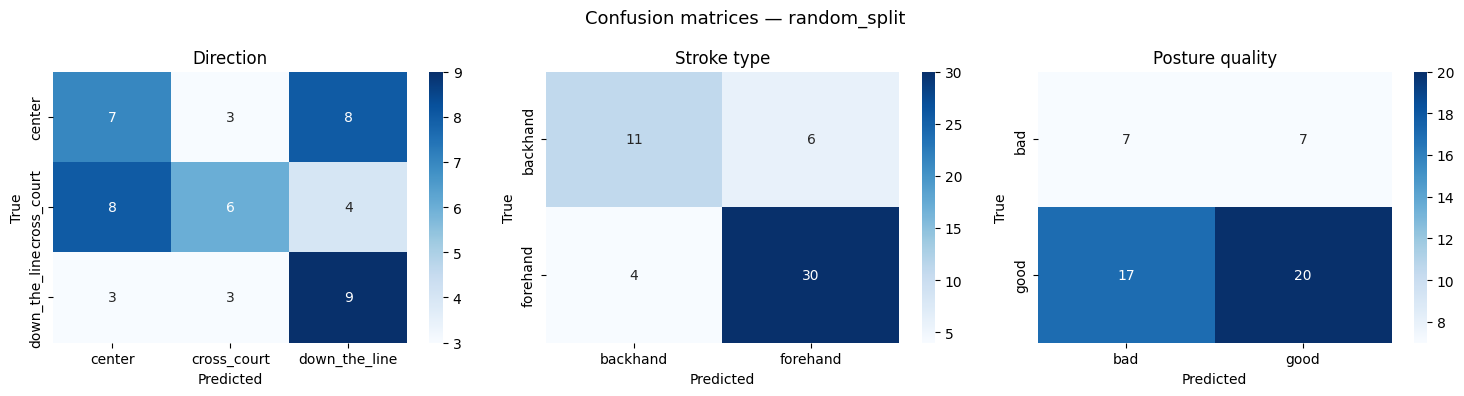


Evaluation — cross_player

Direction prediction:
               precision    recall  f1-score   support

       center       0.25      0.29      0.27        14
  cross_court       0.23      0.62      0.33         8
down_the_line       0.00      0.00      0.00        16

     accuracy                           0.24        38
    macro avg       0.16      0.30      0.20        38
 weighted avg       0.14      0.24      0.17        38

Stroke type prediction:
              precision    recall  f1-score   support

    backhand       0.26      0.45      0.33        11
    forehand       0.68      0.48      0.57        27

    accuracy                           0.47        38
   macro avg       0.47      0.47      0.45        38
weighted avg       0.56      0.47      0.50        38

Posture quality prediction:
              precision    recall  f1-score   support

         bad       0.18      0.40      0.25        10
        good       0.62      0.36      0.45        28

    accuracy       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


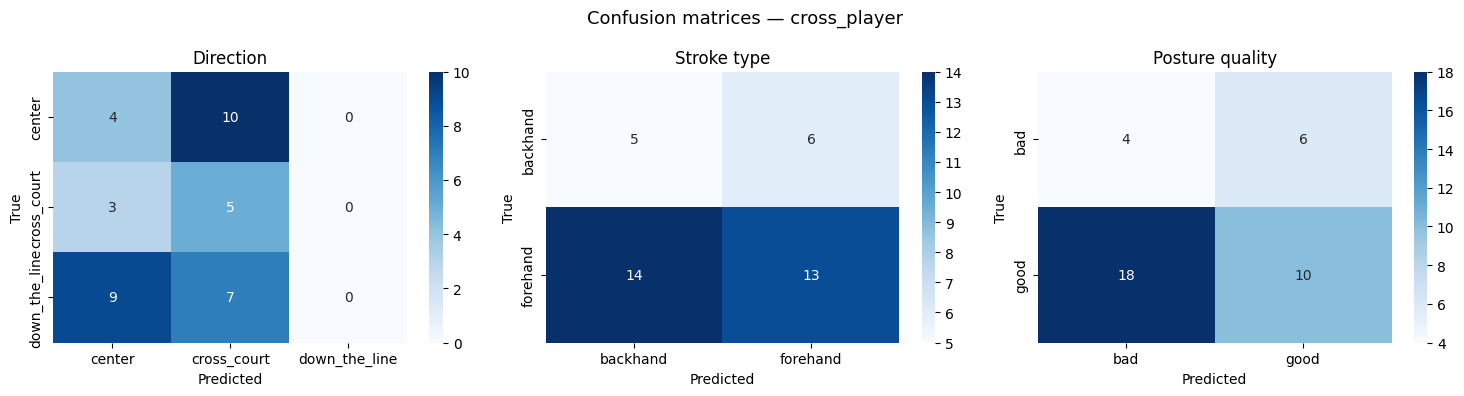

In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, loader, tag=''):
    model.eval()
    all_dir_true, all_dir_pred = [], []
    all_str_true, all_str_pred = [], []
    all_pos_true, all_pos_pred = [], []

    with torch.no_grad():
        for X_b, d_b, s_b, p_b in loader:
            X_b = X_b.to(DEVICE)
            d_out, s_out, p_out = model(X_b)
            all_dir_true.extend(d_b.numpy())
            all_dir_pred.extend(d_out.argmax(1).cpu().numpy())
            all_str_true.extend(s_b.numpy())
            all_str_pred.extend(s_out.argmax(1).cpu().numpy())
            all_pos_true.extend(p_b.numpy())
            all_pos_pred.extend(p_out.argmax(1).cpu().numpy())

    dir_labels = list(mappings['direction'].keys())
    str_labels = list(mappings['stroke_type'].keys())
    pos_labels = list(mappings['posture_quality'].keys())

    print(f"\n{'='*50}")
    print(f"Evaluation — {tag}")
    print(f"{'='*50}")

    print("\nDirection prediction:")
    print(classification_report(all_dir_true, all_dir_pred, target_names=dir_labels))

    print("Stroke type prediction:")
    print(classification_report(all_str_true, all_str_pred, target_names=str_labels))

    print("Posture quality prediction:")
    print(classification_report(all_pos_true, all_pos_pred, target_names=pos_labels))

    # Confusion matrices
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Confusion matrices — {tag}', fontsize=13)

    for ax, (true, pred, labels, title) in zip(axes, [
        (all_dir_true, all_dir_pred, dir_labels, 'Direction'),
        (all_str_true, all_str_pred, str_labels, 'Stroke type'),
        (all_pos_true, all_pos_pred, pos_labels, 'Posture quality')
    ]):
        cm = confusion_matrix(true, pred)
        sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    xticklabels=labels, yticklabels=labels, cmap='Blues')
        ax.set_title(title)
        ax.set_ylabel('True')
        ax.set_xlabel('Predicted')

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/confusion_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Evaluate both models
evaluate_model(model_random, val_loader, tag='random_split')
evaluate_model(model_cross, jiggs_loader, tag='cross_player')

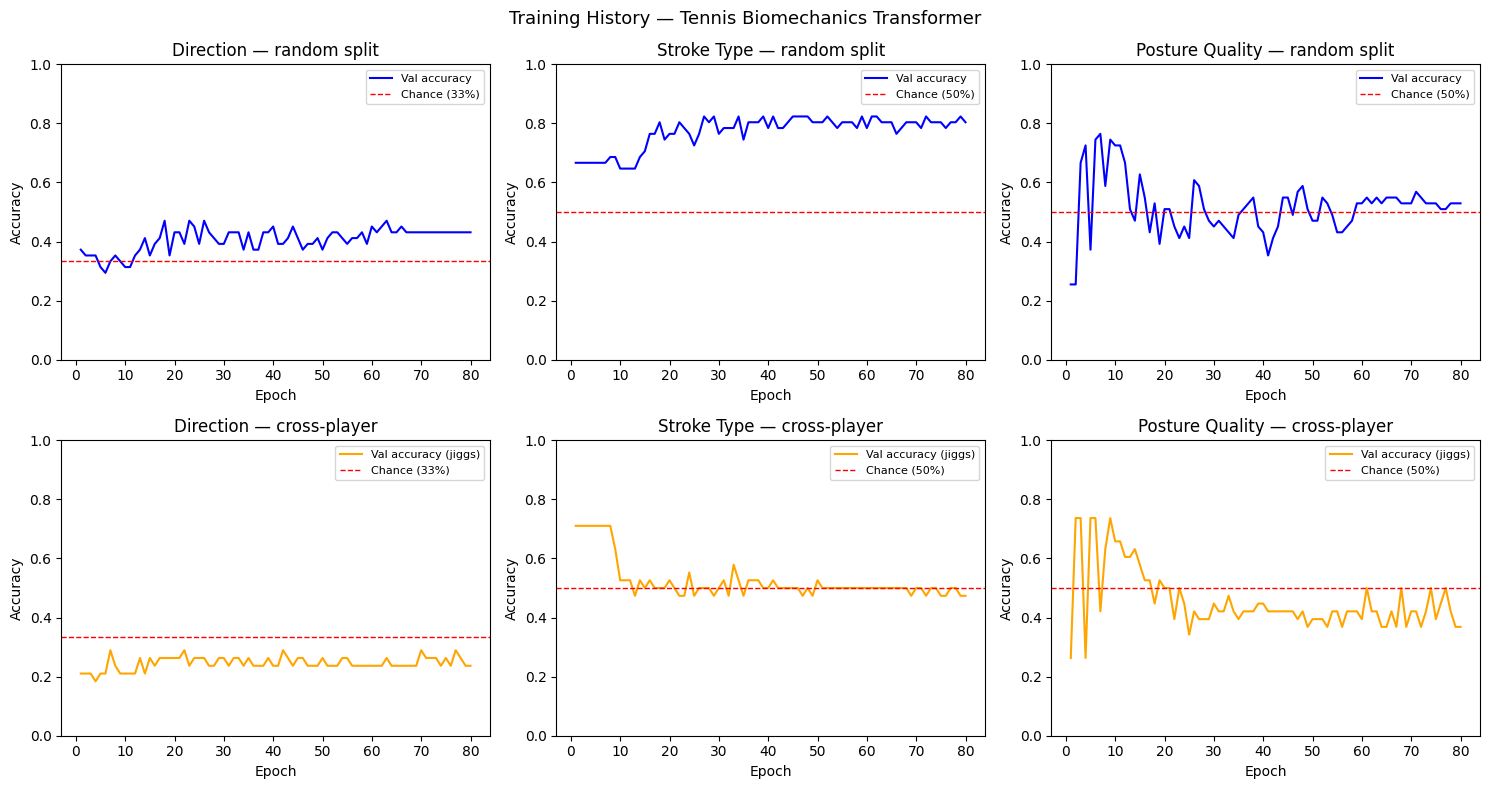

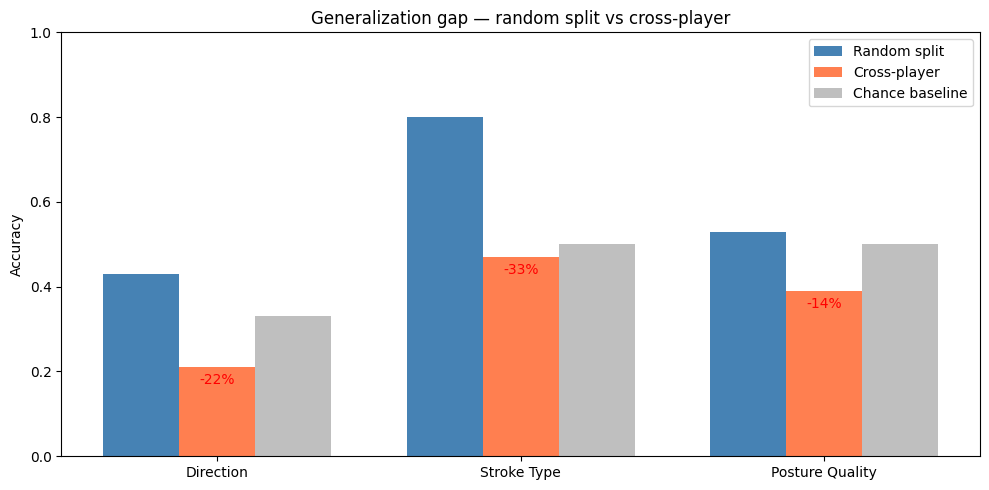

Saved training_history.png and generalization_gap.png


In [36]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history_random, history_cross):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Training History — Tennis Biomechanics Transformer', fontsize=13)

    epochs = range(1, len(history_random['train_loss']) + 1)

    tasks = ['dir', 'str', 'pos']
    task_names = ['Direction', 'Stroke Type', 'Posture Quality']
    chance = [0.333, 0.5, 0.5]

    # Row 1: Random split
    for col, (task, name, ch) in enumerate(zip(tasks, task_names, chance)):
        ax = axes[0, col]
        ax.plot(epochs, history_random[f'val_{task}_acc'], label='Val accuracy', color='blue')
        ax.axhline(ch, color='red', linestyle='--', linewidth=1, label=f'Chance ({ch:.0%})')
        ax.set_title(f'{name} — random split')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.legend(fontsize=8)
        ax.set_ylim(0, 1)

    # Row 2: Cross-player
    for col, (task, name, ch) in enumerate(zip(tasks, task_names, chance)):
        ax = axes[1, col]
        ax.plot(epochs, history_cross[f'val_{task}_acc'], label='Val accuracy (jiggs)', color='orange')
        ax.axhline(ch, color='red', linestyle='--', linewidth=1, label=f'Chance ({ch:.0%})')
        ax.set_title(f'{name} — cross-player')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.legend(fontsize=8)
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig('/kaggle/working/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

# Generalization gap summary
def plot_generalization_gap():
    tasks = ['Direction', 'Stroke Type', 'Posture Quality']
    random_acc = [0.43, 0.80, 0.53]
    cross_acc  = [0.21, 0.47, 0.39]
    chance     = [0.33, 0.50, 0.50]

    x = np.arange(len(tasks))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width, random_acc, width, label='Random split', color='steelblue')
    ax.bar(x,         cross_acc,  width, label='Cross-player', color='coral')
    ax.bar(x + width, chance,     width, label='Chance baseline', color='gray', alpha=0.5)

    ax.set_ylabel('Accuracy')
    ax.set_title('Generalization gap — random split vs cross-player')
    ax.set_xticks(x)
    ax.set_xticklabels(tasks)
    ax.legend()
    ax.set_ylim(0, 1)
    ax.axhline(0, color='black', linewidth=0.5)

    for i, (r, c) in enumerate(zip(random_acc, cross_acc)):
        ax.annotate(f'-{r-c:.0%}', xy=(i, min(r,c) - 0.04),
                    ha='center', fontsize=10, color='red')

    plt.tight_layout()
    plt.savefig('/kaggle/working/generalization_gap.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history_random, history_cross)
plot_generalization_gap()
print("Saved training_history.png and generalization_gap.png")

In [37]:
# Save all final outputs
import json

# Save final results summary
results = {
    'dataset': {
        'total_strokes': 255,
        'players': {'alcaraz': 125, 'federer': 92, 'jiggs': 38},
        'sequence_shape': [255, 30, 39]
    },
    'random_split': {
        'direction_accuracy': 0.43,
        'stroke_accuracy': 0.80,
        'posture_accuracy': 0.53,
        'direction_chance': 0.33
    },
    'cross_player': {
        'direction_accuracy': 0.21,
        'stroke_accuracy': 0.47,
        'posture_accuracy': 0.39,
        'generalization_gap': {
            'direction': -0.22,
            'stroke': -0.33,
            'posture': -0.14
        }
    }
}

with open('/kaggle/working/results_summary.json', 'w') as f:
    json.dump(results, f, indent=2)

print("All outputs saved:")
for f in sorted(os.listdir('/kaggle/working/')):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f"  {f} — {size/1024:.1f} KB")

All outputs saved:
  .virtual_documents — 4.0 KB
  X_sequences.npy — 2331.0 KB
  confusion_cross_player.png — 74.8 KB
  confusion_random_split.png — 72.4 KB
  generalization_gap.png — 45.1 KB
  jiggs_labels_todo.csv — 1.4 KB
  keypoints.csv — 14913.5 KB
  label_encodings.json — 0.2 KB
  labels_clean.csv — 15.9 KB
  labels_final.csv — 17.4 KB
  labels_todo.csv — 12.1 KB
  model_cross_player.pt — 319.2 KB
  model_random_split.pt — 319.2 KB
  pose_landmarker_lite.task — 5642.3 KB
  results_summary.json — 0.5 KB
  stroke_detection_jiggs.png — 374.8 KB
  stroke_windows.csv — 20.2 KB
  training_history.png — 170.5 KB


**Phase 8 — inference**

In [38]:
def extract_sequence_from_image(image_path, seq_len=30):
    """
    Takes a single image and creates a sequence by
    applying slight augmentation to simulate temporal context.
    For real use, pass a video clip instead.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not load image: {image_path}")
        return None, None

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

    with vision.PoseLandmarker.create_from_options(options) as landmarker:
        result = landmarker.detect(mp_image)

    if not result.pose_landmarks or len(result.pose_landmarks) == 0:
        print("No pose detected in image")
        return None, None

    lm = result.pose_landmarks[0]

    # Extract feature vector for this frame
    frame_features = []
    for lm_name in RELEVANT_LANDMARKS:
        idx = LANDMARKS[lm_name]
        frame_features.extend([lm[idx].x, lm[idx].y, lm[idx].z])

    frame_features = np.array(frame_features)  # (39,)

    # Repeat with tiny noise to simulate 30-frame sequence
    # In production this would be actual video frames
    sequence = np.stack([
        frame_features + np.random.normal(0, 0.001, frame_features.shape)
        for _ in range(seq_len)
    ])  # (30, 39)

    return sequence, img

print("Function ready.")

Function ready.


In [39]:
def recommend_shot(direction, stroke_type, posture):
    """Rule-based shot selection advisor."""
    
    rules = {
        ('cross_court', 'forehand', 'bad'):
            ("Consider down_the_line", "Cross-court forehand with poor posture risks errors. "
             "A down-the-line shot requires less wrist rotation."),
        ('cross_court', 'forehand', 'good'):
            ("Optimal shot", "Good cross-court forehand — well executed."),
        ('down_the_line', 'forehand', 'bad'):
            ("Consider cross_court", "Down-the-line with poor posture is high risk. "
             "Cross-court gives more margin."),
        ('down_the_line', 'forehand', 'good'):
            ("Optimal shot", "Strong down-the-line forehand — well executed."),
        ('cross_court', 'backhand', 'bad'):
            ("Consider center", "Cross-court backhand with poor posture — aim center for safety."),
        ('cross_court', 'backhand', 'good'):
            ("Optimal shot", "Clean cross-court backhand."),
        ('down_the_line', 'backhand', 'bad'):
            ("Consider cross_court", "Down-the-line backhand with poor form is risky. "
             "Cross-court is safer."),
        ('down_the_line', 'backhand', 'good'):
            ("Optimal shot", "Excellent down-the-line backhand."),
        ('center', 'forehand', 'bad'):
            ("Work on posture", "Center shot is safe but posture needs improvement."),
        ('center', 'forehand', 'good'):
            ("Good placement", "Solid center forehand."),
        ('center', 'backhand', 'bad'):
            ("Work on posture", "Center backhand — focus on shoulder rotation."),
        ('center', 'backhand', 'good'):
            ("Good placement", "Clean center backhand."),
    }

    key = (direction, stroke_type, posture)
    if key in rules:
        return rules[key]
    return ("No recommendation", "Combination not in rule set.")


def run_inference(image_path):
    print(f"\nRunning inference on: {image_path}")
    print("="*50)

    # Step 1 — extract sequence
    sequence, original_img = extract_sequence_from_image(image_path)
    if sequence is None:
        return

    # Step 2 — model prediction
    model_random.eval()
    X_input = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        dir_out, str_out, pos_out = model_random(X_input)

    dir_probs = torch.softmax(dir_out, dim=1).cpu().numpy()[0]
    str_probs = torch.softmax(str_out, dim=1).cpu().numpy()[0]
    pos_probs = torch.softmax(pos_out, dim=1).cpu().numpy()[0]

    dir_pred = direction_enc.classes_[dir_probs.argmax()]
    str_pred = stroke_enc.classes_[str_probs.argmax()]
    pos_pred = posture_enc.classes_[pos_probs.argmax()]

    dir_conf = dir_probs.max()
    str_conf = str_probs.max()
    pos_conf = pos_probs.max()

    # Step 3 — shot recommendation
    recommendation, explanation = recommend_shot(dir_pred, str_pred, pos_pred)

    # Step 4 — print results
    print(f"Stroke type     : {str_pred} ({str_conf:.1%} confidence)")
    print(f"Direction       : {dir_pred} ({dir_conf:.1%} confidence)")
    print(f"Posture quality : {pos_pred} ({pos_conf:.1%} confidence)")
    print(f"\nShot recommendation: {recommendation}")
    print(f"Explanation        : {explanation}")

    print(f"\nAll class probabilities:")
    print(f"  Direction  : { {c: f'{p:.2%}' for c,p in zip(direction_enc.classes_, dir_probs)} }")
    print(f"  Stroke     : { {c: f'{p:.2%}' for c,p in zip(stroke_enc.classes_, str_probs)} }")
    print(f"  Posture    : { {c: f'{p:.2%}' for c,p in zip(posture_enc.classes_, pos_probs)} }")

    return original_img, dir_pred, str_pred, pos_pred, recommendation, dir_probs

print("Inference function ready.")

Inference function ready.


In [40]:
def compute_angles(lm, h, w):
    def angle(a, b, c):
        a = np.array([lm[a].x * w, lm[a].y * h])
        b = np.array([lm[b].x * w, lm[b].y * h])
        c = np.array([lm[c].x * w, lm[c].y * h])
        ba = a - b
        bc = c - b
        cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
        return np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

    knee  = angle(23, 25, 27)   # left hip-knee-ankle
    elbow = angle(11, 13, 15)   # left shoulder-elbow-wrist
    # X-Factor: shoulder vs hip rotation difference
    shoulder_diff = abs(lm[11].x - lm[12].x)
    hip_diff      = abs(lm[23].x - lm[24].x)
    xfactor = abs(shoulder_diff - hip_diff)
    return knee, elbow, xfactor


print("Ready!!")

Ready!!


In [41]:
def visualize_inference(image_path):
    print(f"Analysing: {image_path}")

    img = cv2.imread(image_path)
    if img is None:
        print("Could not load image — check path")
        return
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    with vision.PoseLandmarker.create_from_options(options) as landmarker:
        pose_result = landmarker.detect(mp_image)

    if not pose_result.pose_landmarks or len(pose_result.pose_landmarks) == 0:
        print("No pose detected — try a clearer image")
        return

    lm = pose_result.pose_landmarks[0]
    h, w = rgb.shape[:2]

    # Draw skeleton
    annotated = rgb.copy()
    connections = [
        (11,12),(11,13),(13,15),(12,14),(14,16),
        (11,23),(12,24),(23,24),(23,25),(24,26),
        (25,27),(26,28)
    ]
    for a, b in connections:
        x1,y1 = int(lm[a].x*w), int(lm[a].y*h)
        x2,y2 = int(lm[b].x*w), int(lm[b].y*h)
        cv2.line(annotated, (x1,y1), (x2,y2), (0,255,0), 2)
    for name, idx in LANDMARKS.items():
        x,y = int(lm[idx].x*w), int(lm[idx].y*h)
        cv2.circle(annotated, (x,y), 5, (255,50,50), -1)

    # Run model inference
    frame_features = []
    for lm_name in RELEVANT_LANDMARKS:
        idx = LANDMARKS[lm_name]
        frame_features.extend([lm[idx].x, lm[idx].y, lm[idx].z])
    frame_features = np.array(frame_features)
    sequence = np.stack([
        frame_features + np.random.normal(0, 0.001, frame_features.shape)
        for _ in range(30)
    ])

    model_random.eval()
    X_input = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        dir_out, str_out, pos_out = model_random(X_input)

    dir_probs = torch.softmax(dir_out, dim=1).cpu().numpy()[0]
    str_probs = torch.softmax(str_out, dim=1).cpu().numpy()[0]
    pos_probs = torch.softmax(pos_out, dim=1).cpu().numpy()[0]

    dir_pred = direction_enc.classes_[dir_probs.argmax()]
    str_pred = stroke_enc.classes_[str_probs.argmax()]
    pos_pred = posture_enc.classes_[pos_probs.argmax()]
    dir_conf = dir_probs.max()
    str_conf = str_probs.max()
    pos_conf = pos_probs.max()

    recommendation, explanation = recommend_shot(dir_pred, str_pred, pos_pred)
    knee, elbow, xfactor = compute_angles(lm, h, w)

    # Direction arrow
    #arrow_targets = {
    #    'cross_court':   (w-40,  h//2),
    #    'down_the_line': (w//2,  40),
    #    'center':        (w//2,  h//2)
    #}
    #if dir_pred in arrow_targets:
    #    cv2.arrowedLine(annotated,
    #                    (w//2, h-40),
    #                    arrow_targets[dir_pred],
    #                    (0, 200, 255), 3, tipLength=0.25)

    # Layout
    fig = plt.figure(figsize=(14, 7), facecolor='#0d1117')
    gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1])
    ax_img   = fig.add_subplot(gs[0])
    ax_panel = fig.add_subplot(gs[1])

    # Left — annotated image
    ax_img.imshow(annotated)
    ax_img.set_title('Pose Detection', color='white', fontsize=12, pad=8)
    ax_img.axis('off')

    # Right — dark panel
    ax_panel.set_facecolor('#0d1117')
    ax_panel.set_xlim(0, 1)
    ax_panel.set_ylim(0, 1)
    ax_panel.axis('off')
    ax_panel.set_title('AI Analysis', color='white', fontsize=12, pad=8)

    def add_section(ax, y, label, value, conf, color):
        ax.text(0.5, y+0.06, label,
                transform=ax.transAxes, ha='center',
                fontsize=9, color='#8b949e', fontweight='normal',
                family='monospace')
        ax.text(0.5, y,
                value.upper().replace('_', ' '),
                transform=ax.transAxes, ha='center',
                fontsize=18, color=color, fontweight='bold')
        ax.text(0.5, y-0.06,
                f'Confidence: {conf:.1%}',
                transform=ax.transAxes, ha='center',
                fontsize=9, color='#8b949e')

    # Direction
    add_section(ax_panel, 0.80, 'SHOT DIRECTION', dir_pred, dir_conf, '#58a6ff')

    # Dividers
    for y_pos in [0.65, 0.37, 0.10]:
        ax_panel.plot([0.1, 0.9], [y_pos, y_pos],
                      color='#30363d', linewidth=0.8,
                      transform=ax_panel.transAxes)

    # Technique
    pos_color = '#3fb950' if pos_pred == 'good' else '#f85149'
    add_section(ax_panel, 0.52, 'TECHNIQUE', pos_pred, pos_conf, pos_color)

    # Shot selection
    sel_color = '#3fb950' if 'Optimal' in recommendation else '#d29922'
    ax_panel.text(0.5, 0.30, 'SHOT SELECTION',
                  transform=ax_panel.transAxes, ha='center',
                  fontsize=9, color='#8b949e', family='monospace')
    ax_panel.text(0.5, 0.23, recommendation.upper(),
                  transform=ax_panel.transAxes, ha='center',
                  fontsize=16, color=sel_color, fontweight='bold')
    ax_panel.text(0.5, 0.16, explanation,
                  transform=ax_panel.transAxes, ha='center',
                  fontsize=8, color='#8b949e', style='italic')

    # Key metrics
    ax_panel.text(0.5, 0.07, 'KEY METRICS',
                  transform=ax_panel.transAxes, ha='center',
                  fontsize=9, color='#8b949e', family='monospace')
    ax_panel.text(0.5, 0.01,
                  f'Knee: {knee:.1f}°    Elbow: {elbow:.1f}°    X-Factor: {xfactor:.4f}',
                  transform=ax_panel.transAxes, ha='center',
                  fontsize=9, color='#3fb950')

    plt.tight_layout(pad=1.5)
    plt.savefig('/kaggle/working/inference_result.png',
                dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f"\nSaved to /kaggle/working/inference_result.png")

    print(f'\nPrediction Summary:')
    print(f'  Direction  : {dir_pred} ({dir_conf*100:.1f}%)')
    print(f'  Technique  : {pos_pred} ({pos_conf*100:.1f}%)')
    print(f'  Selection  : {recommendation} — {explanation}')
    print(f'  Knee angle : {knee:.1f}°')
    print(f'  Elbow angle: {elbow:.1f}°')
    print(f'  X-Factor   : {xfactor:.4f}')

print('Inference function ready.')


Inference function ready.


Analysing: /kaggle/input/datasets/jigyashmanhazarika/tennis-pose-images/Tennis Pose_1.jpeg


I0000 00:00:1775572924.912273      55 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


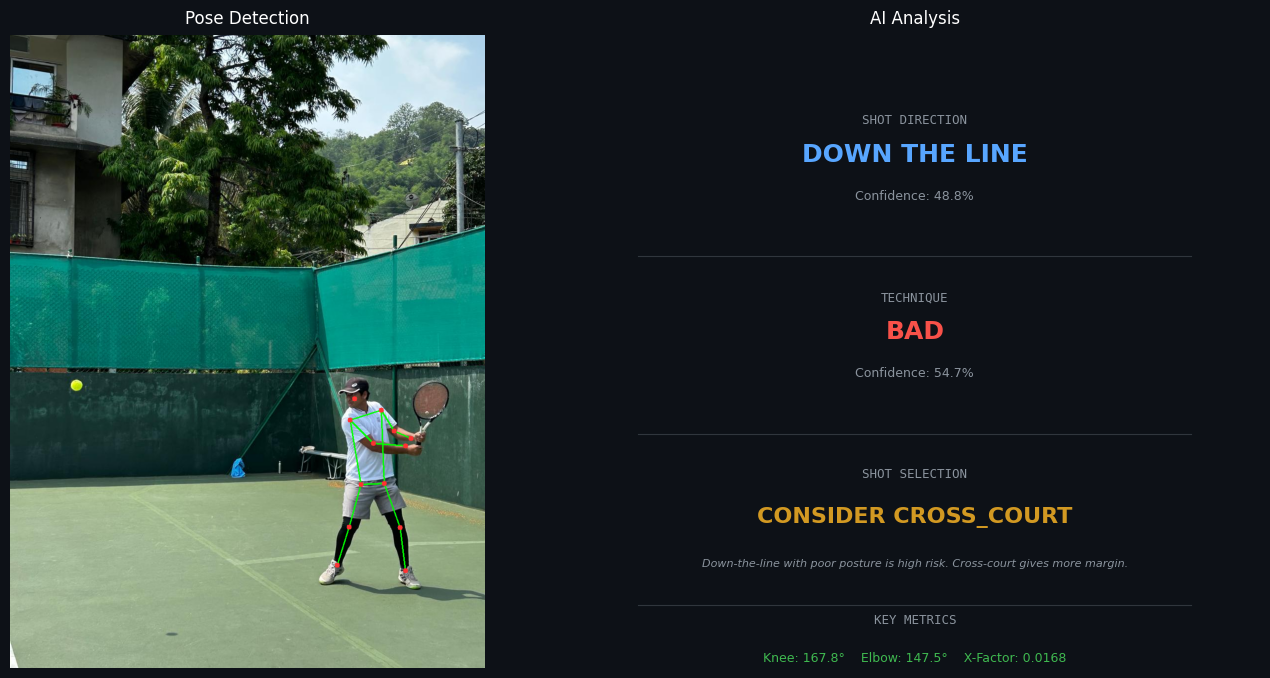


Saved to /kaggle/working/inference_result.png

Prediction Summary:
  Direction  : down_the_line (48.8%)
  Technique  : bad (54.7%)
  Selection  : Consider cross_court — Down-the-line with poor posture is high risk. Cross-court gives more margin.
  Knee angle : 167.8°
  Elbow angle: 147.5°
  X-Factor   : 0.0168


In [42]:
# ================================================
# Change this path to any image you want to test
# ================================================
IMAGE_PATH = '/kaggle/input/datasets/jigyashmanhazarika/tennis-pose-images/Tennis Pose_1.jpeg'
# ================================================

visualize_inference(IMAGE_PATH)

**Phase 9 — Evaluation & Results**

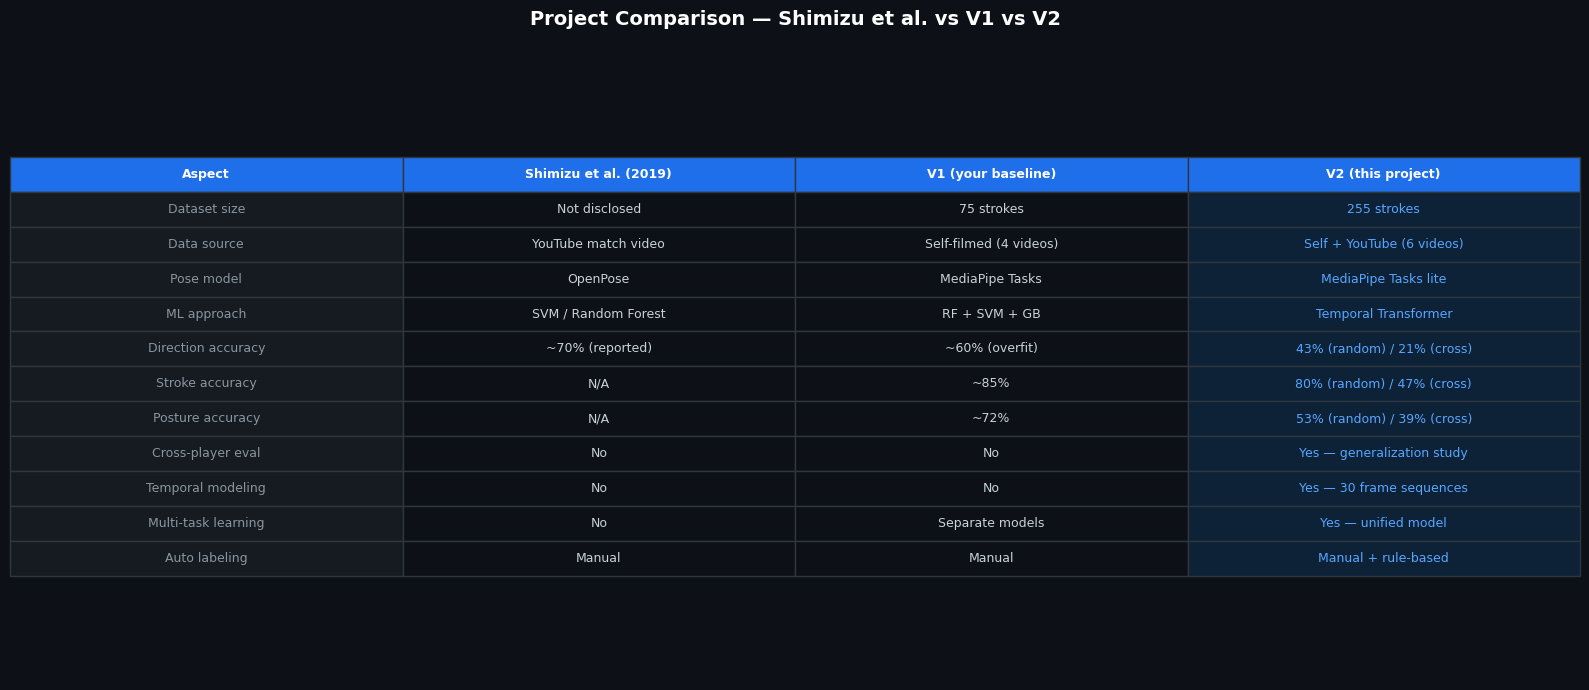

Saved project_comparison.png


In [43]:
comparison_data = {
    'Aspect': [
        'Dataset size',
        'Data source',
        'Pose model',
        'ML approach',
        'Direction accuracy',
        'Stroke accuracy',
        'Posture accuracy',
        'Cross-player eval',
        'Temporal modeling',
        'Multi-task learning',
        'Auto labeling',
    ],
    'Shimizu et al. (2019)': [
        'Not disclosed',
        'YouTube match video',
        'OpenPose',
        'SVM / Random Forest',
        '~70% (reported)',
        'N/A',
        'N/A',
        'No',
        'No',
        'No',
        'Manual',
    ],
    'V1 (your baseline)': [
        '75 strokes',
        'Self-filmed (4 videos)',
        'MediaPipe Tasks',
        'RF + SVM + GB',
        '~60% (overfit)',
        '~85%',
        '~72%',
        'No',
        'No',
        'Separate models',
        'Manual',
    ],
    'V2 (this project)': [
        '255 strokes',
        'Self + YouTube (6 videos)',
        'MediaPipe Tasks lite',
        'Temporal Transformer',
        '43% (random) / 21% (cross)',
        '80% (random) / 47% (cross)',
        '53% (random) / 39% (cross)',
        'Yes — generalization study',
        'Yes — 30 frame sequences',
        'Yes — unified model',
        'Manual + rule-based',
    ]
}

comparison_df = pd.DataFrame(comparison_data)

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.axis('off')

ax.set_title('Project Comparison — Shimizu et al. vs V1 vs V2',
             color='white', fontsize=14, pad=20, fontweight='bold')

col_colors = ['#161b22', '#1f2937', '#0d2137']
col_widths  = [0.28, 0.24, 0.24, 0.24]

table = ax.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#30363d')
    if row == 0:
        cell.set_facecolor('#1f6feb')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 0:
        cell.set_facecolor('#161b22')
        cell.set_text_props(color='#8b949e')
    elif col == 3:
        cell.set_facecolor('#0d2137')
        cell.set_text_props(color='#58a6ff')
    else:
        cell.set_facecolor('#0d1117')
        cell.set_text_props(color='#c9d1d9')

plt.tight_layout()
plt.savefig('/kaggle/working/project_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved project_comparison.png")

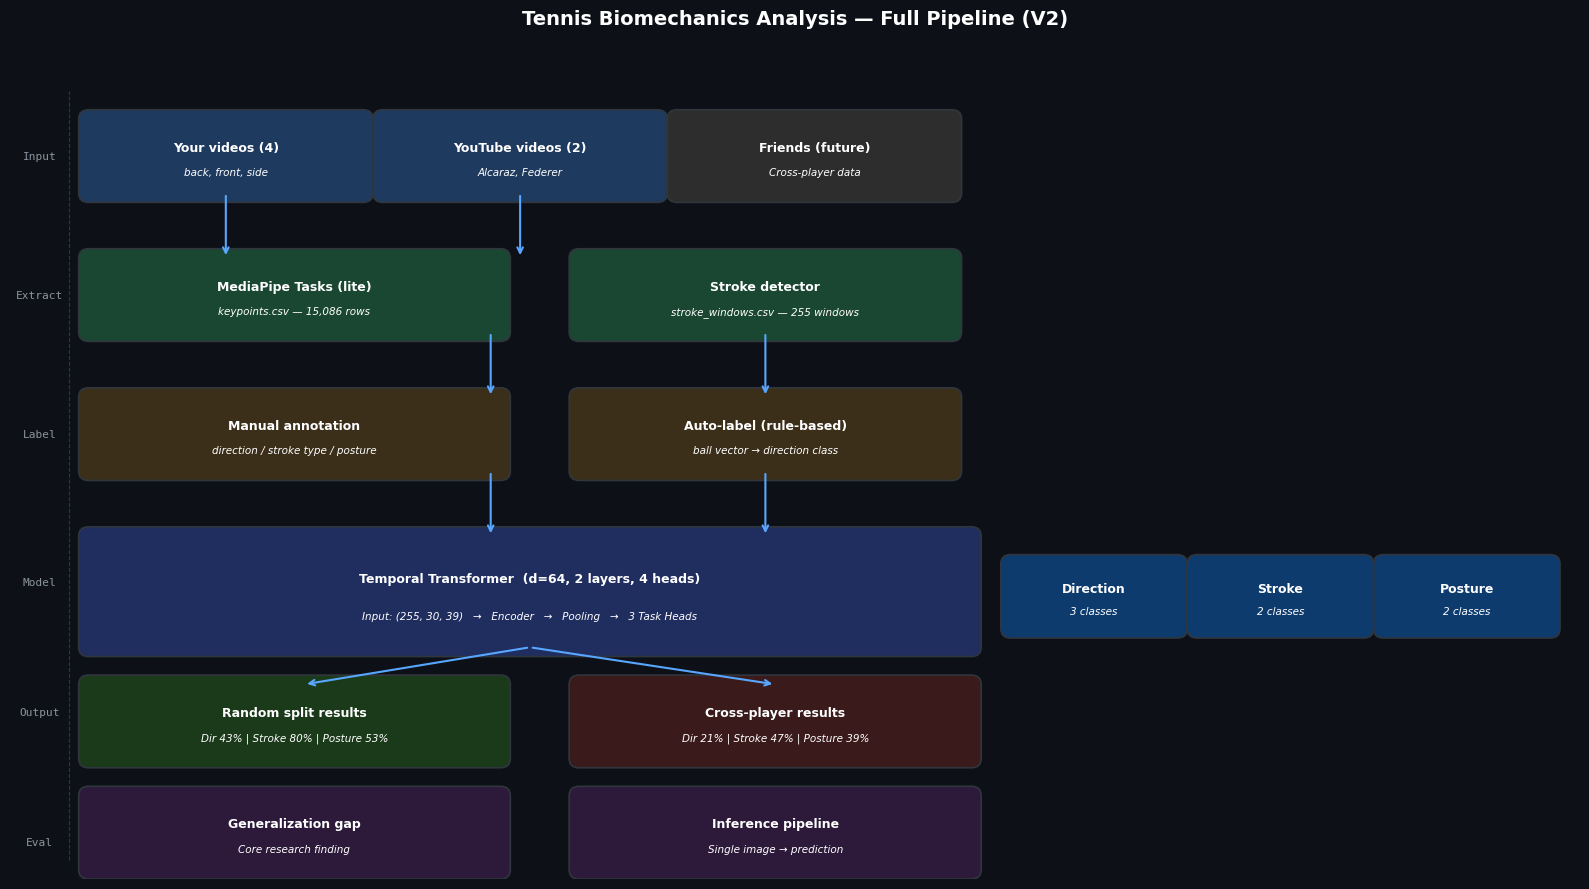

Saved pipeline_diagram.png


In [44]:
fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis('off')

ax.set_title('Tennis Biomechanics Analysis — Full Pipeline (V2)',
             color='white', fontsize=14, pad=15, fontweight='bold')

def draw_box(ax, x, y, w, h, title, subtitle, color, text_color='white'):
    from matplotlib.patches import FancyBboxPatch
    box = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor='#30363d',
                          linewidth=1.2)
    ax.add_patch(box)
    ax.text(x + w/2, y + h*0.62, title,
            ha='center', va='center', color='white',
            fontsize=9, fontweight='bold')
    ax.text(x + w/2, y + h*0.28, subtitle,
            ha='center', va='center', color=text_color,
            fontsize=7.5, style='italic')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#58a6ff',
                                lw=1.5))

# Phase labels on left
phases = ['Input', 'Extract', 'Label', 'Model', 'Output', 'Eval']
y_positions = [7.8, 6.3, 4.8, 3.2, 1.8, 0.4]
for phase, yp in zip(phases, y_positions):
    ax.text(0.3, yp, phase, ha='center', va='center',
            color='#8b949e', fontsize=8, family='monospace')

ax.plot([0.6, 0.6], [0.2, 8.5], color='#30363d',
        linewidth=0.8, linestyle='--')

# Row 1 — Input
draw_box(ax, 0.8, 7.4, 2.8, 0.8, 'Your videos (4)',
         'back, front, side', '#1f3a5f')
draw_box(ax, 3.8, 7.4, 2.8, 0.8, 'YouTube videos (2)',
         'Alcaraz, Federer', '#1f3a5f')
draw_box(ax, 6.8, 7.4, 2.8, 0.8, 'Friends (future)',
         'Cross-player data', '#2d2d2d')

# Row 2 — Extract
draw_box(ax, 0.8, 5.9, 4.2, 0.8, 'MediaPipe Tasks (lite)',
         'keypoints.csv — 15,086 rows', '#1a4731')
draw_box(ax, 5.8, 5.9, 3.8, 0.8, 'Stroke detector',
         'stroke_windows.csv — 255 windows', '#1a4731')

# Row 3 — Label
draw_box(ax, 0.8, 4.4, 4.2, 0.8, 'Manual annotation',
         'direction / stroke type / posture', '#3b2f1a')
draw_box(ax, 5.8, 4.4, 3.8, 0.8, 'Auto-label (rule-based)',
         'ball vector → direction class', '#3b2f1a')

# Row 4 — Model
draw_box(ax, 0.8, 2.5, 9.0, 1.2,
         'Temporal Transformer  (d=64, 2 layers, 4 heads)',
         'Input: (255, 30, 39)   →   Encoder   →   Pooling   →   3 Task Heads',
         '#1f2d5f')

# Task heads
draw_box(ax, 10.2, 2.7, 1.7, 0.7, 'Direction', '3 classes', '#0d3b6e')
draw_box(ax, 12.1, 2.7, 1.7, 0.7, 'Stroke', '2 classes', '#0d3b6e')
draw_box(ax, 14.0, 2.7, 1.7, 0.7, 'Posture', '2 classes', '#0d3b6e')

# Row 5 — Output
draw_box(ax, 0.8, 1.3, 4.2, 0.8, 'Random split results',
         'Dir 43% | Stroke 80% | Posture 53%', '#1a3a1a')
draw_box(ax, 5.8, 1.3, 4.0, 0.8, 'Cross-player results',
         'Dir 21% | Stroke 47% | Posture 39%', '#3a1a1a')

# Row 6 — Eval
draw_box(ax, 0.8, 0.1, 4.2, 0.8, 'Generalization gap',
         'Core research finding', '#2d1a3a')
draw_box(ax, 5.8, 0.1, 4.0, 0.8, 'Inference pipeline',
         'Single image → prediction', '#2d1a3a')

# Arrows
draw_arrow(ax, 2.2, 7.4, 2.2, 6.7)
draw_arrow(ax, 5.2, 7.4, 5.2, 6.7)
draw_arrow(ax, 4.9, 5.9, 4.9, 5.2)
draw_arrow(ax, 7.7, 5.9, 7.7, 5.2)
draw_arrow(ax, 4.9, 4.4, 4.9, 3.7)
draw_arrow(ax, 7.7, 4.4, 7.7, 3.7)
draw_arrow(ax, 5.3, 2.5, 3.0, 2.1)
draw_arrow(ax, 5.3, 2.5, 7.8, 2.1)

plt.tight_layout()
plt.savefig('/kaggle/working/pipeline_diagram.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved pipeline_diagram.png")